# How every number is computed

This notebook follows a detection number from the raw tensors a GPU job wrote to disk all the way to a cell of a paper table, on real models, with nothing but the cached files. It is written for a reader who comes to the project cold. Every term is defined where it first appears, every step says which question forced it and why it is done this way and not another, and every figure says what its axes are, what to look at and what it leaves unproven. No number in the prose is typed by hand. Every value is computed from the files on disk or read from the constant in the code that defines it, and rendered into the text by the cell that computed it, so the notebook cannot go stale against the results it describes.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

In [2]:
import datetime
import inspect
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sklearn.metrics import roc_curve

from cli.analyze import analyze_one_rate
from cli.compare_detectors import psbd_rate, psbd_values
from data.registry import DATASET_REGISTRY
from data.splits import PSBD_HELDOUT_SIZE, PSBD_SPLIT_SEED, psbd_split_permutation
from defenses.cache import (
    baseline_path,
    dropout_pass_path,
    load_baseline,
    load_dropout_pass_probs,
    read_run_provenance,
    read_split_manifest,
)
from defenses.decision import (
    ADAPTIVE_SHIFT_TARGET,
    HEADLINE_QUANTILE,
    PLACEMENT_MATCH_TARGET,
    PSBD_QUANTILES,
    PUBLISHED_PLACEMENT,
    RECOMMENDED_PLACEMENT,
    detection_report,
    pair_clean_to_backdoor,
    select_rate_adaptively,
    select_rate_at_matched_shift,
    shift_key,
    threshold_at_quantile,
)
from defenses.scores import psu_from_cache, psu_ratio_from_cache, shift_ratio
from detectors import DETECTOR_NAMES
from scripts.all_numbers import MATCHED_SUFFIX
from scripts.coverage_ledger import (
    DIVERGENCE_FRACTION,
    SOURCE_MAPPED_ACCURACY,
    classify_by_asr,
    load_declaration,
    source_classes_of,
    success_verdicts,
)
from scripts.paper._common import (
    BOOTSTRAP_RESAMPLES,
    BOOTSTRAP_SEED,
    bootstrap_ci,
    load_psbd_metrics,
    word_list,
)

In [3]:
import scripts.paper._style  # noqa: F401  the figure style every paper figure uses

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline

In [4]:
RESULTS = "results"
EXAMPLE = "vit_tiny_wanet_0_05"
TACT = "vit_cifar10_tact_0_01"
SIG = "vit_cifar10_sig_0_1"
TM = RECOMMENDED_PLACEMENT
RD = PUBLISHED_PLACEMENT
SPLITS = ("validation", "clean", "backdoor")
BUDGETS = (0.10, 0.20)
CLEAN_COLOR, TRIGGERED_COLOR, VALIDATION_COLOR = "#0072B2", "#D55E00", "#009E73"

declaration = load_declaration("configs/psbd_basis.json")
table = pd.read_csv(f"{RESULTS}/all_numbers/all_numbers.csv")
with open(f"{RESULTS}/all_numbers/all_numbers.json") as handle:
    all_numbers = json.load(handle)
models = pd.DataFrame(all_numbers["models"])
vit = table[(table.architecture == "vit") & (table.kind == "attack")]
with open("paper/headline.json") as handle:
    paper_macros = json.load(handle)

# The headline population: ViT models that are successful backdoors at the
# headline bar (successful_2pt) and carry both PSBD-TM and PSBD-RD at the
# adaptive rule, the population of the paper's headline.
both = (
    vit[vit.successful_2pt.astype(bool) & vit.defense.isin(["PSBD-TM", "PSBD-RD"]) & (vit.status == "scored")]
    .groupby("folder_name")
    .defense.nunique()
)
PANEL = sorted(both[both == 2].index)
example_model = models.set_index("folder_name").loc[EXAMPLE]
tm_provenance = read_run_provenance(f"{RESULTS}/{EXAMPLE}/psbd", TM)
K = tm_provenance["forward_passes"]

In [5]:
def say(text):
    display(Markdown(text))


def macro(name):
    value = paper_macros[name]["value"]
    return value


def show_source(function, start=None, stop=None):
    lines = inspect.getsource(function).splitlines()
    excerpt = "\n".join(lines[start:stop])
    path = os.path.relpath(inspect.getsourcefile(function), REPO_ROOT)
    say(f"`{path}`, `{function.__name__}`\n\n```python\n{excerpt}\n```")


def load_rate(folder, placement, rate):
    psbd_dir = f"{RESULTS}/{folder}/psbd"
    loaded = {"manifest": read_split_manifest(psbd_dir)}
    for split in SPLITS:
        probs, labels, loader_labels = load_baseline(baseline_path(psbd_dir, split))
        pass_probs, pass_argmax = load_dropout_pass_probs(
            dropout_pass_path(psbd_dir, placement, rate, split)
        )
        loaded[split] = {
            "probs": probs,  # (n, classes) unperturbed softmax
            "labels": labels,  # (n,) unperturbed argmax
            "loader_labels": loader_labels,  # (n,) true label, or the target on backdoor
            "pass_probs": pass_probs,  # (k, n) probability of the unperturbed argmax
            "pass_argmax": pass_argmax,  # (k, n) argmax of each perturbed pass
        }
    return loaded


def fractional_psu(split):
    scores = psu_ratio_from_cache(split["probs"], split["labels"], split["pass_probs"])  # (n,)
    return scores


def absolute_psu(split):
    scores = psu_from_cache(split["probs"], split["labels"], split["pass_probs"])  # (n,)
    return scores


def per_input_shift(split):
    # the share of the k passes whose argmax left the unperturbed argmax
    moved = split["pass_argmax"].long() != split["labels"].view(1, -1).long()  # (k, n)
    shares = moved.float().mean(dim=0)  # (n,)
    return shares


def tracked_and_mean(split):
    tracked = split["probs"].gather(1, split["labels"].view(-1, 1).long()).squeeze(1)  # (n,)
    perturbed_mean = split["pass_probs"].float().mean(dim=0)  # (n,)
    return tracked, perturbed_mean


def one_sided_auroc(clean_scores, backdoor_scores):
    # The library's own AUROC, detection_report. The threshold does not enter
    # AUROC, so the clean scores stand in for the validation set here.
    clean = torch.as_tensor(np.asarray(clean_scores, dtype=np.float32))
    backdoor = torch.as_tensor(np.asarray(backdoor_scores, dtype=np.float32))
    auroc = detection_report(clean, clean, backdoor, HEADLINE_QUANTILE)["auroc"]
    return auroc


def reading(folder, defense, field="auroc"):
    row = table[(table.folder_name == folder) & (table.defense == defense)]
    assert len(row) == 1, (folder, defense, len(row))
    value = row[field].iloc[0]
    return value


def model_words(folder):
    model = models.set_index("folder_name").loc[folder]
    words = f"`{folder}` ({model.attack} at {model.poison_rate:.0%} poisoning on {model.dataset})"
    return words

In [6]:
say(f'''
The project asks whether Prediction Shift Backdoor Detection (PSBD, Li et al., arXiv 2406.05826), a test-time detector built for convolutional networks, works on Vision Transformers. A backdoored model classifies ordinary images correctly but sends any image carrying a trigger (a small patch, a blended pattern, a warp) to a target class the attacker chose. The attack success rate (ASR) is the share of triggered images that land on the target, and the clean accuracy is the ordinary test accuracy. PSBD asks whether an input is triggered by perturbing the model a little and watching whether its prediction holds: a triggered input rides a short, robust path to the target and barely moves, while a clean input loses confidence.

The chain the notebook walks has these stages, 1 section each.

- The files a number is read from, and the 2 stages of the pipeline that write them.
- The PSBD split: {PSBD_HELDOUT_SIZE} clean validation images and a pool of clean test images paired with triggered copies of the same images.
- The $k$ = {K} perturbed passes at 1 placement and 1 rate.
- The shift ratio $\\sigma$, Li et al.'s measure of how strong a perturbation is.
- Prediction shift uncertainty (PSU) in its absolute form and the fractional form every table reads.
- 2 measurements that justify the score: PSU against the per-input shift ratio, and PSU against plain confidence.
- The adaptive rate rule (clean validation shift ratio reaches {ADAPTIVE_SHIFT_TARGET}) and the matched rule (nearest {PLACEMENT_MATCH_TARGET}), which choose the rate.
- The quantile threshold, TPR at each false-positive budget and the realized FPR.
- AUROC and its fixed direction, and a model where AUROC and TPR disagree.
- The success bars that decide which models a mean spans, a clean accuracy drop of at most {-declaration["clean_accuracy_drop_bar_headline"] * 100:.0f} and {-declaration["clean_accuracy_drop_bar"] * 100:.0f} points.
- The paired gain between 2 placements and its bootstrap interval.
- The rank among defenses and the margin interval against the strongest competitor.

2 names recur throughout. **PSBD-TM** is token masking at the attention input of every block (`{TM}`), the placement the paper recommends. **PSBD-RD** is dropout after both residual additions of every block (`{RD}`), our adaptation of the site the original paper used in a ResNet. The running example is {model_words(EXAMPLE)}, a ViT-B/16 with a warping trigger, chosen because WaNet is a hard attack and Tiny ImageNet a primary dataset, so the example is not flattered by an easy case. The notebook runs on a CPU in about a minute. The table of every reading is `results/all_numbers/all_numbers.csv`, written by `scripts/all_numbers.py`, the formulas are collected in `docs/metrics.md` and `notebooks/all-numbers.ipynb` lays out every number by poison rate, attack and defense. The **headline population** used for the measurements below holds the {len(PANEL)} ViT models that clear the ASR bar and carry both PSBD-TM and PSBD-RD, the population the paper's headline is computed on.
''')


The project asks whether Prediction Shift Backdoor Detection (PSBD, Li et al., arXiv 2406.05826), a test-time detector built for convolutional networks, works on Vision Transformers. A backdoored model classifies ordinary images correctly but sends any image carrying a trigger (a small patch, a blended pattern, a warp) to a target class the attacker chose. The attack success rate (ASR) is the share of triggered images that land on the target, and the clean accuracy is the ordinary test accuracy. PSBD asks whether an input is triggered by perturbing the model a little and watching whether its prediction holds: a triggered input rides a short, robust path to the target and barely moves, while a clean input loses confidence.

The chain the notebook walks has these stages, 1 section each.

- The files a number is read from, and the 2 stages of the pipeline that write them.
- The PSBD split: 2000 clean validation images and a pool of clean test images paired with triggered copies of the same images.
- The $k$ = 3 perturbed passes at 1 placement and 1 rate.
- The shift ratio $\sigma$, Li et al.'s measure of how strong a perturbation is.
- Prediction shift uncertainty (PSU) in its absolute form and the fractional form every table reads.
- 2 measurements that justify the score: PSU against the per-input shift ratio, and PSU against plain confidence.
- The adaptive rate rule (clean validation shift ratio reaches 0.8) and the matched rule (nearest 0.6), which choose the rate.
- The quantile threshold, TPR at each false-positive budget and the realized FPR.
- AUROC and its fixed direction, and a model where AUROC and TPR disagree.
- The success bars that decide which models a mean spans, a clean accuracy drop of at most 2 and 5 points.
- The paired gain between 2 placements and its bootstrap interval.
- The rank among defenses and the margin interval against the strongest competitor.

2 names recur throughout. **PSBD-TM** is token masking at the attention input of every block (`before_attention_norm_token_mask`), the placement the paper recommends. **PSBD-RD** is dropout after both residual additions of every block (`post_residual`), our adaptation of the site the original paper used in a ResNet. The running example is `vit_tiny_wanet_0_05` (wanet at 5% poisoning on tiny), a ViT-B/16 with a warping trigger, chosen because WaNet is a hard attack and Tiny ImageNet a primary dataset, so the example is not flattered by an easy case. The notebook runs on a CPU in about a minute. The table of every reading is `results/all_numbers/all_numbers.csv`, written by `scripts/all_numbers.py`, the formulas are collected in `docs/metrics.md` and `notebooks/all-numbers.ipynb` lays out every number by poison rate, attack and defense. The **headline population** used for the measurements below holds the 54 ViT models that clear the ASR bar and carry both PSBD-TM and PSBD-RD, the population the paper's headline is computed on.


## The files a number is read from

The first question is where a number physically comes from, because every later step either reads or recomputes 1 of these files. The pipeline has 2 stages, split so that the expensive part runs once. Stage 1, `cli.sweep`, runs on a GPU: it loads a checkpoint, builds the split, runs the unperturbed model once and the perturbed model $k$ times per rate, and writes only raw tensors. Stage 2, `cli.analyze`, runs on a CPU in seconds: it reads those tensors and writes every metric into `results/<folder>/psbd_metrics.json`. I rejected computing metrics inside the GPU job because every change to a scoring rule, a quantile or a rate rule would then need a new GPU run, while with raw tensors on disk the whole metric layer can be reconsidered in seconds, and this notebook can recompute every number without a GPU.

| file | written by | holds |
|---|---|---|
| `checkpoints/<folder>/args.json` | `training.loop.save_checkpoint`, then `cli.evaluate` | training provenance, ASR, clean accuracy |
| `results/<folder>/psbd/split_manifest.json` | `cli.sweep` | the original test indices of the validation, clean and backdoor splits, in row order |
| `results/<folder>/psbd/baseline_<split>.pt` | `cli.sweep` | the unperturbed softmax, its argmax and the label the loader served |
| `results/<folder>/psbd/<placement>/rate_<tag>_<split>.pt` | `cli.sweep` | the $(k, n)$ perturbed probabilities and argmax classes at 1 rate |
| `results/<folder>/psbd/run_<placement>.json` | `cli.sweep` | commit, position, operator, $k$, mask seed and device of the sweep |
| `results/<folder>/psbd_metrics.json` | `cli.analyze` | every metric of every placement at every rate, and the rate rules' choices |
| `results/<folder>/detectors/<name>_metrics.json` | `cli.baselines` | a competitor detector's metrics on the same split |
| `results/coverage/coverage.json` | `scripts/coverage_ledger.py` | 1 verdict per panel model: ASR class, divergence, source mapping, success bars |
| `results/all_numbers/all_numbers.csv` | `scripts/all_numbers.py` | 1 row per (model, defense), every reading above in 1 table |
| `paper/headline.json` | `scripts/paper/headline.py` | every number the paper prints, as a named macro |

A **placement** names both where the perturbation is injected (the **position**, for example the input of the attention sublayer before its LayerNorm) and what it does there (the **operator**, for example token masking). The directory name `before_attention_norm_token_mask` is the position followed by the operator, and a bare `post_residual` means dropout, the operator that contributes no suffix. `cli.analyze.analyze_one_rate` turns 1 rate's tensors into every metric. The next cell reruns it on the example and checks it against the stored record, so everything the later sections recompute by hand is tied to the stored file.

In [7]:
psbd_dir = f"{RESULTS}/{EXAMPLE}/psbd"
report = load_psbd_metrics(RESULTS, EXAMPLE)
example_rate = psbd_rate(report["placements"][TM], "adaptive")
show_source(analyze_one_rate, start=0, stop=12)

# analyze_one_rate reads the baselines and the manifest, the same inputs cli.analyze passes it.
baselines = {split: load_baseline(baseline_path(psbd_dir, split)) for split in SPLITS}
num_classes = DATASET_REGISTRY[example_model.dataset].num_classes
rerun = analyze_one_rate(psbd_dir, TM, example_rate, baselines, read_split_manifest(psbd_dir), num_classes, int(example_model.target_label))
stored_row = next(row for row in report["placements"][TM]["rates"] if row["rate"] == example_rate)
largest_gap = max(
    abs(rerun["detection_psu_ratio"][key][field] - stored_row["detection_psu_ratio"][key][field])
    for key in stored_row["detection_psu_ratio"]
    for field in ("auroc", "tpr", "fpr", "threshold")
)
assert largest_gap < 1e-9
say(f'''
`{EXAMPLE}` carries {len(report["placements"])} cached placements, and the adaptive rule chose rate {example_rate:g} for PSBD-TM. Rerunning `analyze_one_rate` on its cached tensors reproduces every AUROC, TPR, FPR and threshold of the stored `detection_psu_ratio` block, with a largest difference of {largest_gap:.1e}. The stored `psbd_metrics.json` of this model is therefore exactly what the current code computes from the current tensors. That check says nothing about whether the tensors themselves are current, which is the job of the ledger's stale-baseline column, and the confidence section below finds a model where 2 sets of tensors disagree. The next question is which images those tensors describe.
''')

`cli/analyze.py`, `analyze_one_rate`

```python
def analyze_one_rate(
    psbd_dir: str,
    placement: str,
    rate: float,
    baselines: dict,
    manifest: dict,
    num_classes: int,
    target_label: int | None,
) -> dict:
    """Every number for a (position_config, rate): sigma, shifts and detection.

    The clean split is paired down to the backdoor split's images before the
```


`vit_tiny_wanet_0_05` carries 39 cached placements, and the adaptive rule chose rate 0.5 for PSBD-TM. Rerunning `analyze_one_rate` on its cached tensors reproduces every AUROC, TPR, FPR and threshold of the stored `detection_psu_ratio` block, with a largest difference of 0.0e+00. The stored `psbd_metrics.json` of this model is therefore exactly what the current code computes from the current tensors. That check says nothing about whether the tensors themselves are current, which is the job of the ledger's stale-baseline column, and the confidence section below finds a model where 2 sets of tensors disagree. The next question is which images those tensors describe.


In [8]:
example = load_rate(EXAMPLE, TM, example_rate)
manifest = example["manifest"]
clean_indices = manifest["analysis_clean_indices"]
backdoor_indices = manifest["analysis_backdoor_indices"]
assert len(manifest["heldout_indices"]) == PSBD_HELDOUT_SIZE
assert set(manifest["heldout_indices"]).isdisjoint(clean_indices)
assert set(backdoor_indices) <= set(clean_indices)

say(f'''
## The PSBD split

Every number is computed on the same 3 sets of images, so the split comes first. The test set of a dataset is shuffled once by `psbd_split_permutation` with seed `PSBD_SPLIT_SEED` = {PSBD_SPLIT_SEED}. The seed depends on the dataset only, never on the attack or the model, so every model of a dataset sees the identical split and 2 models can be compared image by image.

- **Validation**: the first `PSBD_HELDOUT_SIZE` = {PSBD_HELDOUT_SIZE} images of the permutation, clean. This is the only data the defender is assumed to hold, and every threshold and every rate choice reads these images and nothing else.
- **Clean**: the remaining images, clean, the analysis pool.
- **Backdoor**: the images of the analysis pool the attack is allowed to act on, stamped with the trigger. `attacks.poisoning.is_eval_poisonable` decides which. For an all-to-one attack it is every class except the target, since a target-class image is already classified as the target and cannot show success. For TaCT it is the source classes only. For a clean-label attack it is every non-target class.

`pair_clean_to_backdoor` restricts the clean scores to exactly the images behind the backdoor rows, in the same order, so a triggered image is always compared with its own clean copy. Without it the clean side would contain the target class and the backdoor side would not, and FPR and AUROC would partly measure which classes were dropped. The original PSBD scores the poisoned training set. This project scores a clean test pool instead, because a test pool with paired triggered copies gives a known label for every image and a comparison where the 2 populations differ by the trigger alone. The repository records no reason for the validation size. On the example's test set of {manifest["n_total"]} images it is {PSBD_HELDOUT_SIZE / manifest["n_total"]:.0%}, and a {BUDGETS[0]:.2f} quantile of it rests on {int(BUDGETS[0] * PSBD_HELDOUT_SIZE)} images.
''')
show_source(psbd_split_permutation)
show_source(pair_clean_to_backdoor, start=-6)


## The PSBD split

Every number is computed on the same 3 sets of images, so the split comes first. The test set of a dataset is shuffled once by `psbd_split_permutation` with seed `PSBD_SPLIT_SEED` = 0. The seed depends on the dataset only, never on the attack or the model, so every model of a dataset sees the identical split and 2 models can be compared image by image.

- **Validation**: the first `PSBD_HELDOUT_SIZE` = 2000 images of the permutation, clean. This is the only data the defender is assumed to hold, and every threshold and every rate choice reads these images and nothing else.
- **Clean**: the remaining images, clean, the analysis pool.
- **Backdoor**: the images of the analysis pool the attack is allowed to act on, stamped with the trigger. `attacks.poisoning.is_eval_poisonable` decides which. For an all-to-one attack it is every class except the target, since a target-class image is already classified as the target and cannot show success. For TaCT it is the source classes only. For a clean-label attack it is every non-target class.

`pair_clean_to_backdoor` restricts the clean scores to exactly the images behind the backdoor rows, in the same order, so a triggered image is always compared with its own clean copy. Without it the clean side would contain the target class and the backdoor side would not, and FPR and AUROC would partly measure which classes were dropped. The original PSBD scores the poisoned training set. This project scores a clean test pool instead, because a test pool with paired triggered copies gives a known label for every image and a comparison where the 2 populations differ by the trigger alone. The repository records no reason for the validation size. On the example's test set of 10000 images it is 20%, and a 0.10 quantile of it rests on 200 images.


`data/splits.py`, `psbd_split_permutation`

```python
def psbd_split_permutation(n_total: int, seed: int = PSBD_SPLIT_SEED) -> torch.Tensor:
    """The single permutation the whole PSBD split derives from, shape (n_total,).

    seed_everything then torch.randperm as the first RNG consumption, so anything
    that reloads the same test set and reruns these 2 lines recovers which original
    test index maps to which saved tensor row. The sweep and every reproduction call
    this same definition, so they cannot drift.
    """
    seed_everything(seed)
    permutation = torch.randperm(n_total)
    return permutation
```

`defenses/decision.py`, `pair_clean_to_backdoor`

```python

    row_of = {original: row for row, original in enumerate(clean_indices)}
    rows = [row_of[original] for original in backdoor_indices]

    paired = clean_scores[torch.tensor(rows, dtype=torch.long)]  # (n_backdoor,)
    return paired
```

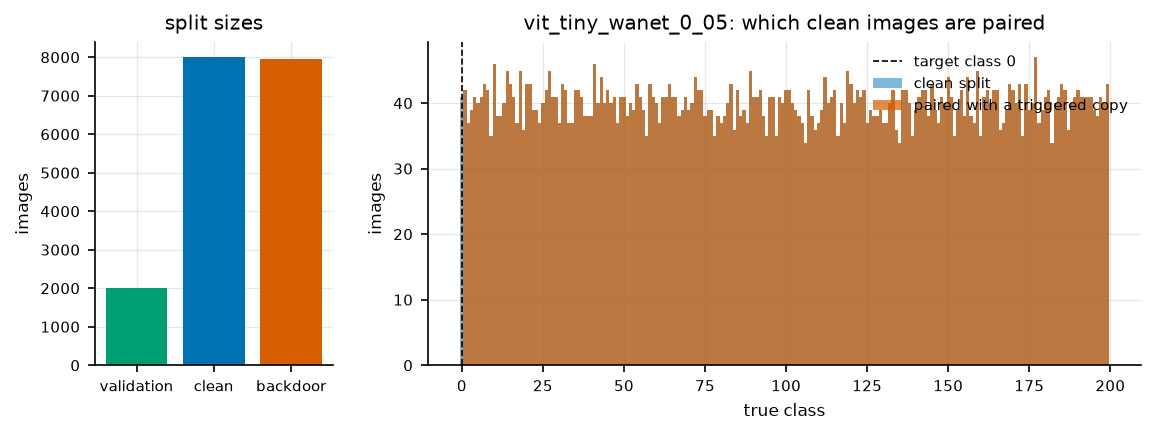


The left panel shows the split sizes of the example: 2000 validation, 8000 clean and 7959 triggered images. The right panel shows, per true class on the horizontal axis, how many clean images the analysis pool holds (blue) and how many of them have a triggered copy (orange). The reader should look at the dashed line: the target class 0 has 0 triggered copies, and every other class keeps all of its images. The split is disjoint by construction, which the asserts above check. What the figure does not show is whether 2000 validation images are enough for a stable threshold, which is why the realized FPR is measured on the paired clean images in a later section rather than assumed equal to the budget. With the images fixed, the next question is what the perturbation does to a single one of them.


In [9]:
clean_true = example["clean"]["loader_labels"]  # (n_clean,) true labels
paired_true = pair_clean_to_backdoor(clean_true, manifest)  # (n_backdoor,) labels of the paired clean copies
target = int(example_model.target_label)

figure, (sizes_axis, classes_axis) = plt.subplots(1, 2, figsize=(9, 2.8), gridspec_kw={"width_ratios": [1, 3]})
sizes_axis.bar(["validation", "clean", "backdoor"], [len(manifest["heldout_indices"]), len(clean_indices), len(backdoor_indices)], color=[VALIDATION_COLOR, CLEAN_COLOR, TRIGGERED_COLOR])
sizes_axis.set_ylabel("images")
sizes_axis.set_title("split sizes")
classes = np.arange(num_classes)
classes_axis.bar(classes, np.bincount(clean_true.numpy(), minlength=num_classes), color=CLEAN_COLOR, width=1.0, alpha=0.5, label="clean split")
classes_axis.bar(classes, np.bincount(paired_true.numpy(), minlength=num_classes), color=TRIGGERED_COLOR, width=1.0, alpha=0.7, label="paired with a triggered copy")
classes_axis.axvline(target, color="black", linewidth=0.8, linestyle="--", label=f"target class {target}")
classes_axis.set_xlabel("true class")
classes_axis.set_ylabel("images")
classes_axis.set_title(f"{EXAMPLE}: which clean images are paired")
classes_axis.legend()
plt.show()

say(f'''
The left panel shows the split sizes of the example: {len(manifest["heldout_indices"])} validation, {len(clean_indices)} clean and {len(backdoor_indices)} triggered images. The right panel shows, per true class on the horizontal axis, how many clean images the analysis pool holds (blue) and how many of them have a triggered copy (orange). The reader should look at the dashed line: the target class {target} has {int((paired_true == target).sum())} triggered copies, and every other class keeps all of its images. The split is disjoint by construction, which the asserts above check. What the figure does not show is whether {PSBD_HELDOUT_SIZE} validation images are enough for a stable threshold, which is why the realized FPR is measured on the paired clean images in a later section rather than assumed equal to the budget. With the images fixed, the next question is what the perturbation does to a single one of them.
''')

In [10]:
say(f'''
## The perturbed passes

PSBD runs the model once unperturbed and then $k$ more times with a perturbation switched on. `models.positions.plug_dropout` attaches a fresh perturbation module at the named position of every transformer block through forward hooks, and `unplug_dropout` removes it again. A fresh module is used rather than switching on the model's own dropout, because a trained dropout's rescaling was calibrated against the next layer's weights, and turning it back on would mix the model's regularization with the probe.

For PSBD-TM the operator is `defenses.operators.TokenMask`. In every block, before the attention LayerNorm, each token vector is zeroed independently with probability $p$ (the **rate**), the surviving tokens are rescaled by $1 / (1 - p)$ so the expected activation is unchanged, and token 0, the class token, is never masked because it is the only token the classifier reads. PSBD-RD's operator is ordinary dropout on the residual stream after both residual additions, independently per coordinate.

The sweep of the example records $k$ = {K} (`forward_passes`), mask seed {tm_provenance["mask_seed"]}, bfloat16 inference {"on" if tm_provenance["use_bfloat16"] else "off"}, the device `{tm_provenance["device"]}` and the rate ladder {tm_provenance["dropout_rates"]}. $k$ = {K} is the value the original paper uses. The paper's appendix measures what more passes add: over the {macro("PassAllCells")} headline models PSBD-TM's mean AUROC is {macro("PassAllAurocKOne")} at $k$ = 1, {macro("PassAllAurocKTwo")} at $k$ = 2 and {macro("PassAllAurocKThree")} at $k$ = 3 (`paper/headline.json`, from `scripts/paper/fig_forward_passes.py`). `docs/open-questions.md` (Q3) records that the curve has not converged, so $k$ = {K} is a fidelity choice that leaves some AUROC on the table. The mask generator is reseeded before each split, so a rerun reproduces the same masks. For every placement, rate and split `cli.sweep` writes 2 tensors of shape $(k, n)$: the probability each perturbed pass gives to the class the unperturbed model predicted and the class each pass itself predicted. Everything downstream is arithmetic on these 2 tensors and the unperturbed softmax.
''')
show_source(load_dropout_pass_probs)


## The perturbed passes

PSBD runs the model once unperturbed and then $k$ more times with a perturbation switched on. `models.positions.plug_dropout` attaches a fresh perturbation module at the named position of every transformer block through forward hooks, and `unplug_dropout` removes it again. A fresh module is used rather than switching on the model's own dropout, because a trained dropout's rescaling was calibrated against the next layer's weights, and turning it back on would mix the model's regularization with the probe.

For PSBD-TM the operator is `defenses.operators.TokenMask`. In every block, before the attention LayerNorm, each token vector is zeroed independently with probability $p$ (the **rate**), the surviving tokens are rescaled by $1 / (1 - p)$ so the expected activation is unchanged, and token 0, the class token, is never masked because it is the only token the classifier reads. PSBD-RD's operator is ordinary dropout on the residual stream after both residual additions, independently per coordinate.

The sweep of the example records $k$ = 3 (`forward_passes`), mask seed 0, bfloat16 inference on, the device `NVIDIA A100-SXM4-40GB` and the rate ladder [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]. $k$ = 3 is the value the original paper uses. The paper's appendix measures what more passes add: over the 54 headline models PSBD-TM's mean AUROC is 0.952 at $k$ = 1, 0.960 at $k$ = 2 and 0.963 at $k$ = 3 (`paper/headline.json`, from `scripts/paper/fig_forward_passes.py`). `docs/open-questions.md` (Q3) records that the curve has not converged, so $k$ = 3 is a fidelity choice that leaves some AUROC on the table. The mask generator is reseeded before each split, so a rerun reproduces the same masks. For every placement, rate and split `cli.sweep` writes 2 tensors of shape $(k, n)$: the probability each perturbed pass gives to the class the unperturbed model predicted and the class each pass itself predicted. Everything downstream is arithmetic on these 2 tensors and the unperturbed softmax.


`defenses/cache.py`, `load_dropout_pass_probs`

```python
def load_dropout_pass_probs(path: str) -> tuple[torch.Tensor, torch.Tensor]:
    """(probs, argmax), both (passes, n).

    argmax is absent from files written before it was saved, so it comes back as
    an empty (0, 0) tensor rather than raising. Stage 2 then reports sigma as
    unavailable for those instead of failing the whole checkpoint.
    """
    blob = torch.load(path, map_location="cpu")
    probs = blob["per_pass_probs"]  # (passes, n)
    argmax = blob.get("per_pass_argmax", torch.empty(0, 0, dtype=torch.int16))
    return probs, argmax
```

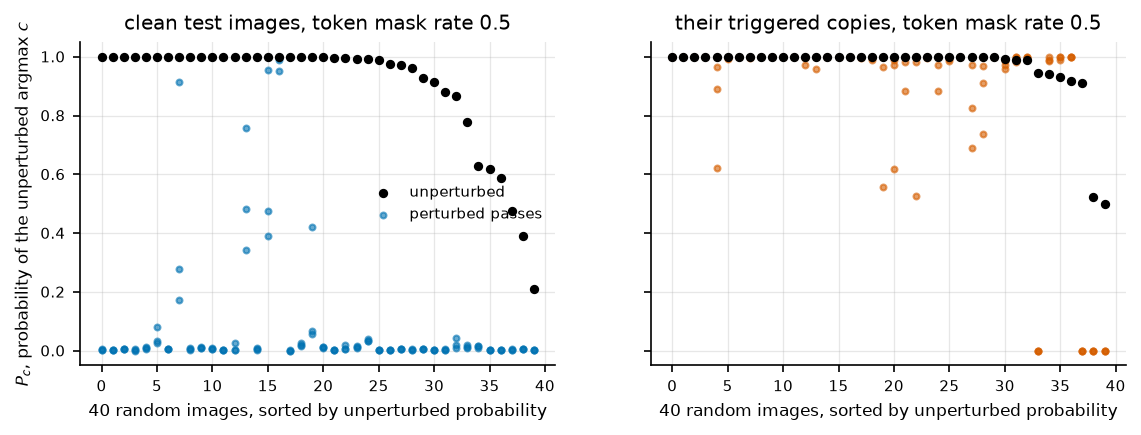


Each column of dots is 1 image, 40 drawn at random per split. The black dot is the probability the unperturbed model gives its own predicted class, and the 3 colored dots are the probability each masked pass gives that same class. The reader should compare the 2 panels: on clean images (left) the masked passes pull the probability far below the black dot, while on the triggered copies (right) they stay near it. This is the premise of PSBD made visible on a handful of images of 1 model at 1 rate. It does not say whether that rate was a sensible one, nor how to turn 3 probabilities into 1 score, nor whether the pattern holds on other models. The next question is how strong the perturbation is, measured in a way that does not depend on where it was injected.


In [11]:
generator = np.random.default_rng(0)
shown_images = 40
figure, axes = plt.subplots(1, 2, figsize=(9, 2.8), sharey=True)
for axis, split, name, color in (
    (axes[0], "clean", "clean test images", CLEAN_COLOR),
    (axes[1], "backdoor", "their triggered copies", TRIGGERED_COLOR),
):
    data = example[split]
    rows = generator.choice(data["probs"].shape[0], shown_images, replace=False)
    unperturbed = data["probs"].gather(1, data["labels"].view(-1, 1).long()).squeeze(1)[rows]  # (shown_images,)
    order = np.argsort(-unperturbed.numpy())
    positions = np.arange(shown_images)
    axis.scatter(positions, unperturbed.numpy()[order], color="black", s=12, label="unperturbed", zorder=3)
    for pass_index in range(data["pass_probs"].shape[0]):
        axis.scatter(positions, data["pass_probs"][pass_index, rows].numpy()[order], color=color, s=8, alpha=0.6, label="perturbed passes" if pass_index == 0 else None)
    axis.set_title(f"{name}, token mask rate {example_rate:g}")
    axis.set_xlabel(f"{shown_images} random images, sorted by unperturbed probability")
axes[0].set_ylabel(r"$P_c$, probability of the unperturbed argmax $c$")
axes[0].legend()
plt.show()

say(f'''
Each column of dots is 1 image, {shown_images} drawn at random per split. The black dot is the probability the unperturbed model gives its own predicted class, and the {K} colored dots are the probability each masked pass gives that same class. The reader should compare the 2 panels: on clean images (left) the masked passes pull the probability far below the black dot, while on the triggered copies (right) they stay near it. This is the premise of PSBD made visible on a handful of images of 1 model at 1 rate. It does not say whether that rate was a sensible one, nor how to turn {K} probabilities into 1 score, nor whether the pattern holds on other models. The next question is how strong the perturbation is, measured in a way that does not depend on where it was injected.
''')

## The shift ratio

A rate means different things at different placements. Masking a share $p$ of tokens at the attention input disturbs the model far less than dropping the same share of the residual stream in every block, which leaves only $(1 - p)^L$ of it intact after $L$ blocks. Li et al. measure the strength of a perturbation by how often it changes the predicted class, which is comparable across placements. In their notation, with $\theta_i'$ the model on perturbed pass $i$,

$$
\phi_{PS}(x; \theta_i') = \mathbb{I}\big(Y(x; \theta) \neq Y(x; \theta_i')\big), \qquad
\sigma(D) = \frac{1}{k\,|D|} \sum_{x \in D} \sum_{i=1}^{k} \phi_{PS}(x; \theta_i')
$$

| symbol | meaning |
|---|---|
| $x$ | an input image |
| $\theta$ | the unperturbed model |
| $\theta_i'$ | the model on perturbed pass $i$ |
| $Y(x; \theta)$ | the predicted class, the argmax of the softmax |
| $\mathbb{I}(\cdot)$ | 1 when the condition holds, 0 otherwise |
| $k$ | perturbed passes per image, `forward_passes` in the run record |
| $D$ | a set of images, the clean validation set when a rate is chosen |
| $\phi_{PS}$ | the prediction shift of 1 image on 1 pass, 0 or 1 |
| $\sigma(D)$ | the shift ratio, the share of all (image, pass) predictions that moved |

`defenses.scores.shift_ratio` computes $\sigma$ from the cached argmax tensors, and `cli.analyze` stores it per split and per rate under `shift_ratio`. The rate rules in a later section read $\sigma$ of the clean validation set only, so they never see a triggered image.

`defenses/scores.py`, `shift_ratio`

```python
        return None

    shifted = (
        per_pass_argmax.long() != baseline_labels.view(1, -1).long()
    )  # (passes, n)

    sigma = float(shifted.float().mean().item())
    return sigma
```

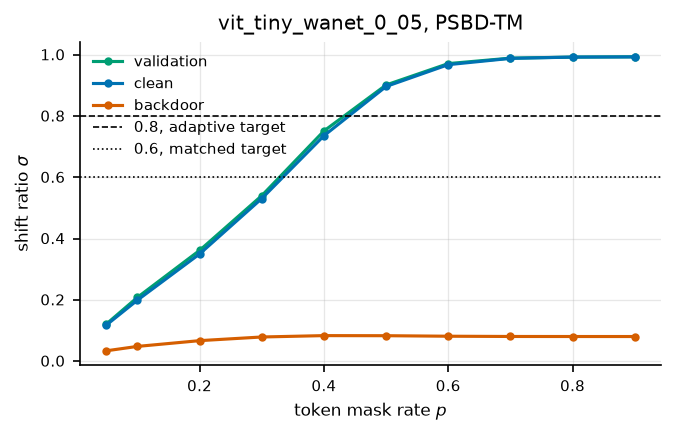

,validation,clean,backdoor,AUROC
rate,,,,
0.05,0.121,0.117,0.033,0.754
0.10,0.208,0.199,0.048,0.812
0.20,0.361,0.350,0.067,0.864
0.30,0.540,0.530,0.079,0.896
0.40,0.751,0.735,0.083,0.922
0.50,0.901,0.896,0.083,0.930
0.60,0.971,0.967,0.081,0.929
0.70,0.989,0.988,0.080,0.928
0.80,0.992,0.992,0.080,0.930



The horizontal axis is the token mask rate on the swept ladder and the vertical axis the shift ratio of each split. The reader should look at 2 things. The validation and clean curves lie on top of each other (the largest gap on the ladder is 0.016), which is what lets a rate chosen on validation transfer to the test pool. The backdoor curve stays at or below 0.083 even at the top of the ladder, where the validation curve reaches 0.993. That gap is what PSBD exploits. $\sigma$ is a statistic of a whole set, so it describes the perturbation and cannot score a single image, which the section after next measures. The table under the figure also lists the AUROC at each rate, a number the rate rules never read. The next question is what number each image gets.


In [12]:
show_source(shift_ratio, start=-8)

ladder = pd.DataFrame(
    [
        {"rate": row["rate"], **{split: row["shift_ratio"][split] for split in SPLITS}, "AUROC": row["detection_psu_ratio"][f"q{HEADLINE_QUANTILE:.2f}"]["auroc"]}
        for row in report["placements"][TM]["rates"]
    ]
).set_index("rate")

# The cached sigma is recomputed from the tensors at the example's rate.
recomputed = shift_ratio(example["validation"]["labels"], example["validation"]["pass_argmax"])
assert abs(recomputed - ladder.loc[example_rate, "validation"]) < 1e-6

figure, axis = plt.subplots(figsize=(5, 2.8))
for split, color in (("validation", VALIDATION_COLOR), ("clean", CLEAN_COLOR), ("backdoor", TRIGGERED_COLOR)):
    axis.plot(ladder.index, ladder[split], marker="o", markersize=3, color=color, label=split)
axis.axhline(ADAPTIVE_SHIFT_TARGET, color="black", linewidth=0.8, linestyle="--", label=f"{ADAPTIVE_SHIFT_TARGET}, adaptive target")
axis.axhline(PLACEMENT_MATCH_TARGET, color="black", linewidth=0.8, linestyle=":", label=f"{PLACEMENT_MATCH_TARGET}, matched target")
axis.set_xlabel("token mask rate $p$")
axis.set_ylabel(r"shift ratio $\sigma$")
axis.set_title(f"{EXAMPLE}, PSBD-TM")
axis.legend()
plt.show()
display(ladder.round(3))

say(f'''
The horizontal axis is the token mask rate on the swept ladder and the vertical axis the shift ratio of each split. The reader should look at 2 things. The validation and clean curves lie on top of each other (the largest gap on the ladder is {float((ladder.validation - ladder.clean).abs().max()):.3f}), which is what lets a rate chosen on validation transfer to the test pool. The backdoor curve stays at or below {ladder.backdoor.max():.3f} even at the top of the ladder, where the validation curve reaches {ladder.validation.max():.3f}. That gap is what PSBD exploits. $\\sigma$ is a statistic of a whole set, so it describes the perturbation and cannot score a single image, which the section after next measures. The table under the figure also lists the AUROC at each rate, a number the rate rules never read. The next question is what number each image gets.
''')

## Prediction shift uncertainty

PSU asks how much the probability of the model's own unperturbed answer falls under the perturbation. Li et al. define it, in their Equation 2, as

$$
\phi_{PSU}(x) = P_c(x; \theta) - \frac{1}{k} \sum_{i=1}^{k} P_c(x; p, \theta_i'), \qquad c = \arg\max_{c'} P_{c'}(x; \theta)
$$

| symbol | meaning |
|---|---|
| $P_c(x; \theta)$ | softmax probability of class $c$ under the unperturbed model |
| $P_c(x; p, \theta_i')$ | the same probability on perturbed pass $i$ at rate $p$ |
| $c$ | the unperturbed argmax, held fixed across the passes |
| $k$ | perturbed passes |
| $\phi_{PSU}(x)$ | the absolute PSU of image $x$ |

The class $c$ is fixed to the unperturbed prediction, so PSU tracks 1 class and does not care which class a pass moved to. A backdoored model routes a triggered image to the target through a path the perturbation does not break, so its probability stays put and its PSU is low. A low score therefore means poisoned, the convention every detector in the repository follows. `defenses.scores.psu_from_cache` is the equation above with no reinterpretation, and `cli.analyze` stores its detection metrics under the `detection` key.

`defenses/scores.py`, `psu_from_cache`

```python
    tracked = baseline_probs.gather(1, baseline_labels.view(-1, 1).long()).squeeze(
        1
    )  # (n,)

    psu = (tracked.float() - per_pass_probs.float().mean(dim=0)).float()  # (n,)
    return psu
```

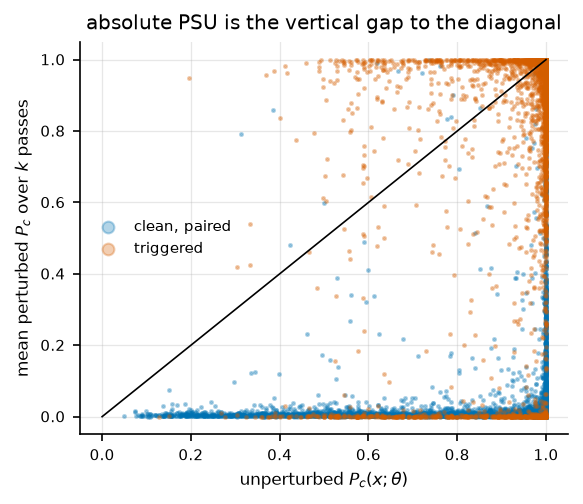


Each point is 1 image of the example at its adaptive rate, 7959 paired clean images and as many triggered copies. The horizontal axis is the unperturbed probability of the predicted class and the vertical axis the mean over the 3 passes of the probability of that same class, so the vertical distance from a point down to the diagonal is its absolute PSU. Triggered images (orange) sit near the diagonal with a median absolute PSU of 0.002. Clean images (blue) spread below it with a median of 0.968. The figure also shows the objection absolute PSU invites: an image that starts at 0.6 cannot fall as far as one that starts at 0.99, so part of the absolute score may be starting confidence. The next section asks whether dividing by the starting probability changes the ranking.


In [13]:
show_source(psu_from_cache, start=-6)

paired_clean = {name: pair_clean_to_backdoor(function(example["clean"]), manifest) for name, function in (("absolute", absolute_psu), ("fractional", fractional_psu))}
triggered = {"absolute": absolute_psu(example["backdoor"]), "fractional": fractional_psu(example["backdoor"])}

clean_tracked, clean_mean = tracked_and_mean(example["clean"])
clean_tracked, clean_mean = pair_clean_to_backdoor(clean_tracked, manifest), pair_clean_to_backdoor(clean_mean, manifest)
backdoor_tracked, backdoor_mean = tracked_and_mean(example["backdoor"])

figure, axis = plt.subplots(figsize=(4.2, 3.4))
axis.scatter(clean_tracked, clean_mean, s=2, alpha=0.3, color=CLEAN_COLOR, label="clean, paired")
axis.scatter(backdoor_tracked, backdoor_mean, s=2, alpha=0.3, color=TRIGGERED_COLOR, label="triggered")
axis.plot([0, 1], [0, 1], color="black", linewidth=0.8)
axis.set_xlabel(r"unperturbed $P_c(x;\theta)$")
axis.set_ylabel(r"mean perturbed $P_c$ over $k$ passes")
axis.set_title("absolute PSU is the vertical gap to the diagonal")
axis.legend(markerscale=4)
plt.show()

say(f'''
Each point is 1 image of the example at its adaptive rate, {len(clean_tracked)} paired clean images and as many triggered copies. The horizontal axis is the unperturbed probability of the predicted class and the vertical axis the mean over the {K} passes of the probability of that same class, so the vertical distance from a point down to the diagonal is its absolute PSU. Triggered images (orange) sit near the diagonal with a median absolute PSU of {float(triggered["absolute"].median()):.3f}. Clean images (blue) spread below it with a median of {float(paired_clean["absolute"].median()):.3f}. The figure also shows the objection absolute PSU invites: an image that starts at 0.6 cannot fall as far as one that starts at 0.99, so part of the absolute score may be starting confidence. The next section asks whether dividing by the starting probability changes the ranking.
''')

## Fractional PSU

The paper reports the fractional form, the drop as a share of the starting probability. In the notation of the equation above,

$$
\phi_{ratio}(x) = 1 - \frac{1}{k} \sum_{i=1}^{k} \frac{P_c(x; p, \theta_i')}{P_c(x; \theta)}
$$

with the same symbols, and with $P_c(x; \theta)$ clamped below at $10^{-6}$ so that an image the model gave almost no probability cannot divide by 0. It is 0 when the passes leave the probability unchanged and 1 when they drive it to 0. It turns negative when they raise it. I chose it over the absolute form for 2 reasons that `defenses/scores.py` records. It removes the confidence objection by construction: if PSU worked only because confident images fall further, dividing by the confidence would destroy the signal. And it is scale free, so a quantile threshold on it does not inherit the calibration of the validation set. Every headline AUROC, TPR and FPR is read from the `detection_psu_ratio` block of `psbd_metrics.json`, which `cli.analyze.analyze_one_rate` fills with `psu_ratio_from_cache`. The absolute form stays beside it under `detection` so the published method remains visible.

`defenses/scores.py`, `psu_ratio_from_cache`

```python
    )  # (n,)

    # Clamped because a sample the model gave almost no probability would
    # otherwise divide by 0 and swamp the whole distribution.
    tracked = tracked.float().clamp_min(1e-6)  # (n,)

    psu_ratio = (
        (tracked - per_pass_probs.float().mean(dim=0)) / tracked
    ).float()  # (n,)
    return psu_ratio
```

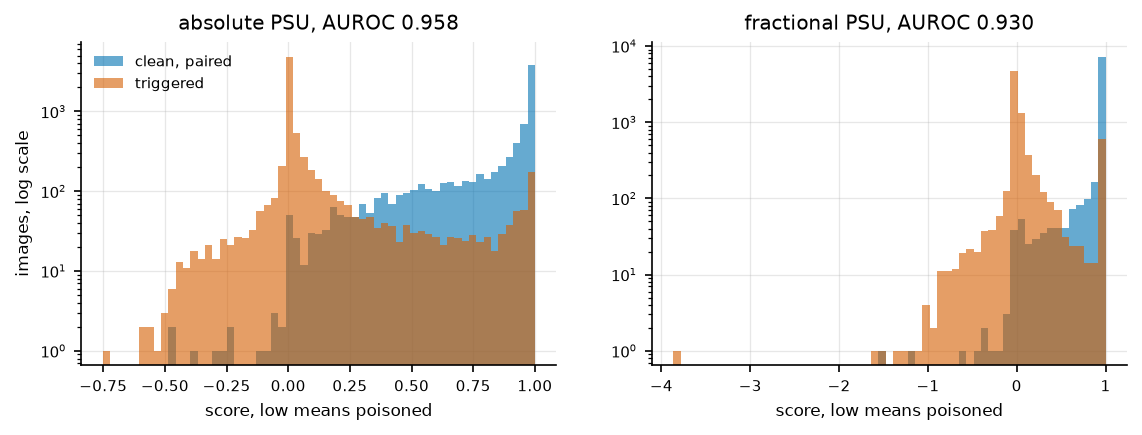


The 2 histograms show the scores of the paired clean images (blue) and of the triggered images (orange) on the example, absolute on the left and fractional on the right, with counts on a log scale. The reader should look at how far the orange mass sits to the left of the blue mass, which is what AUROC summarizes (defined in full below). On this model the 2 forms separate at AUROC 0.958 and 0.930, and the recomputed fractional AUROC equals the reading in `all_numbers.csv`, which ties the table to the tensors. 1 model cannot say which form is better, and neither form has yet been compared with the simpler per-image statistic Li et al. already define. The next section measures all 3 on every model.


In [14]:
show_source(psu_ratio_from_cache, start=-10)

example_auroc = {name: one_sided_auroc(paired_clean[name], triggered[name]) for name in ("absolute", "fractional")}
figure, axes = plt.subplots(1, 2, figsize=(9, 2.8))
for axis, name in zip(axes, ("absolute", "fractional")):
    bins = np.linspace(min(paired_clean[name].min(), triggered[name].min()), max(paired_clean[name].max(), triggered[name].max()), 60)
    axis.hist(paired_clean[name].numpy(), bins=bins, color=CLEAN_COLOR, alpha=0.6, label="clean, paired")
    axis.hist(triggered[name].numpy(), bins=bins, color=TRIGGERED_COLOR, alpha=0.6, label="triggered")
    axis.set_yscale("log")
    axis.set_title(f"{name} PSU, AUROC {example_auroc[name]:.3f}")
    axis.set_xlabel("score, low means poisoned")
axes[0].set_ylabel("images, log scale")
axes[0].legend()
plt.show()

stored = reading(EXAMPLE, "PSBD-TM")
assert abs(example_auroc["fractional"] - stored) < 1e-9
say(f'''
The 2 histograms show the scores of the paired clean images (blue) and of the triggered images (orange) on the example, absolute on the left and fractional on the right, with counts on a log scale. The reader should look at how far the orange mass sits to the left of the blue mass, which is what AUROC summarizes (defined in full below). On this model the 2 forms separate at AUROC {example_auroc["absolute"]:.3f} and {example_auroc["fractional"]:.3f}, and the recomputed fractional AUROC equals the reading in `all_numbers.csv`, which ties the table to the tensors. 1 model cannot say which form is better, and neither form has yet been compared with the simpler per-image statistic Li et al. already define. The next section measures all 3 on every model.
''')

## PSU against the per-input shift ratio

The shift ratio can be applied to 1 image: the share of its $k$ passes whose argmax moved,

$$
\sigma(x) = \frac{1}{k} \sum_{i=1}^{k} \phi_{PS}(x; \theta_i')
$$

A reader could ask why PSBD needs PSU at all, since $\sigma(x)$ is already a per-image score. I expected it to lose for 2 reasons. It takes only $k + 1$ values ($0, 1/k, \dots, 1$), so it cannot rank the many images that share a value, and AUROC gives a tie half credit. And it ignores any fall in probability that keeps the argmax: an image whose probability drops from 0.99 to 0.51 scores exactly like one that did not move. PSU keeps that fall. The measurement below runs on the headline population, at each model's PSBD-TM adaptive rate, with all 3 scores computed from the same cached tensors and the same pairing, so the only difference between the columns is the score. The confidence of the unperturbed model is computed in the same loop for the next section.

In [15]:
def measure_scores(folder):
    data = load_rate(folder, TM, reading(folder, "PSBD-TM", "rate"))
    split_manifest = data["manifest"]
    scores = {
        "per-input shift": per_input_shift,
        "absolute PSU": absolute_psu,
        "fractional PSU": fractional_psu,
        # low means poisoned, and a backdoor makes the model confident, so negated
        "confidence": lambda split: -split["probs"].max(dim=1).values.float(),
    }
    row = {"folder_name": folder}
    for name, function in scores.items():
        clean = pair_clean_to_backdoor(function(data["clean"]), split_manifest)
        row[name] = one_sided_auroc(clean, function(data["backdoor"]))
    return row


measured = pd.DataFrame([measure_scores(folder) for folder in PANEL]).set_index("folder_name")

# The recomputed fractional AUROC is the stored PSBD-TM reading on every model.
stored = pd.Series({folder: reading(folder, "PSBD-TM") for folder in PANEL})
assert (measured["fractional PSU"] - stored).abs().max() < 1e-9
display(measured[["per-input shift", "absolute PSU", "fractional PSU"]].describe().round(3))

,per-input shift,absolute PSU,fractional PSU
count,54.000,54.000,54.000
mean,0.914,0.955,0.963
std,0.104,0.080,0.079
min,0.497,0.484,0.459
25%,0.927,0.958,0.968
50%,0.947,0.979,0.985
75%,0.959,0.993,0.994
max,0.990,1.000,1.000


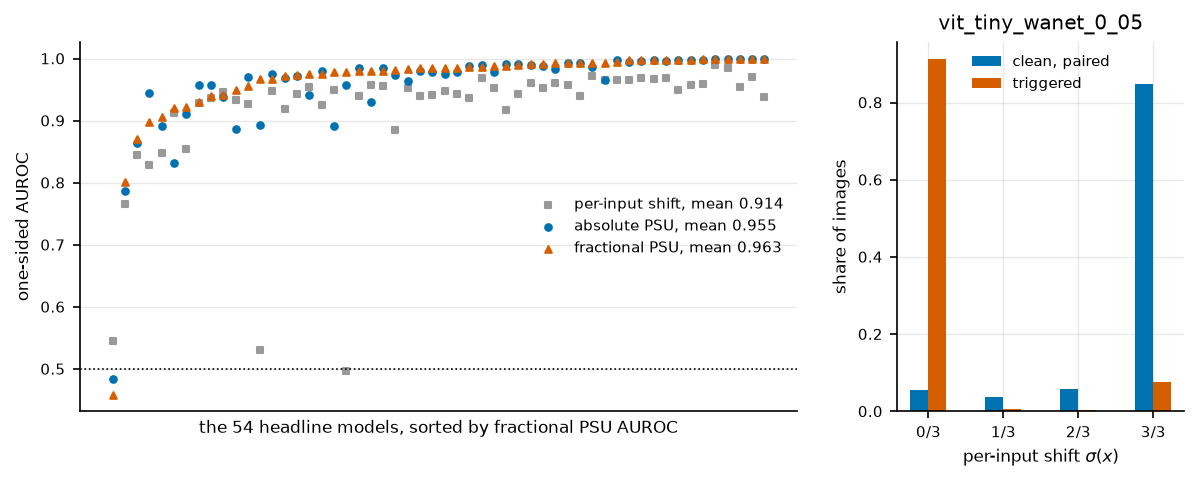


The left panel places the 54 headline models on the horizontal axis in order of their fractional PSU AUROC and shows the AUROC of each of the 3 scores on the vertical axis. The reader should look at the gray squares. The per-input shift averages 0.914 against 0.955 for absolute and 0.963 for fractional PSU. Fractional PSU beats it on 52 of 54 models, by +0.049 on average. The right panel shows why on the example: 91% of the triggered images sit at $\sigma(x) = 0$ and 85% of the clean images at $\sigma(x) = 1$, so a 4 valued score can only rank between those blocks and never inside them.

The clean image at row 495 of the example is the failure the definition predicts, in an extreme form. Its argmax is unchanged on all 3 passes, so its per-input shift is 0 and it scores as untouched, yet the probability of that class falls from 1.000 to 0.036, 0.020 and 0.025 on the 3 passes, an absolute PSU of 0.973. On a dataset with 200 classes the masked passes can flatten the softmax so far that the predicted class keeps the argmax at a tiny probability.

The measurement supports PSU over the per-input shift as the way to score 1 input. Between the 2 PSU forms it shows only a small and inconsistent margin: fractional beats absolute on 36 of 54 models, by +0.008 on average. The choice of the fractional form therefore rests on its argument (no confidence confound, a scale free threshold) more than on this AUROC difference. The measurement is at 1 placement and $k$ = 3, and a larger $k$ would give $\sigma(x)$ more values. The next question is whether PSU is a slow way of reading the model's confidence.


In [16]:
order = measured["fractional PSU"].sort_values().index
figure, (models_axis, values_axis) = plt.subplots(1, 2, figsize=(9.5, 3.2), gridspec_kw={"width_ratios": [3, 1.2]})
positions = np.arange(len(order))
for name, color, marker in (("per-input shift", "#999999", "s"), ("absolute PSU", CLEAN_COLOR, "o"), ("fractional PSU", TRIGGERED_COLOR, "^")):
    models_axis.scatter(positions, measured.loc[order, name], s=10, color=color, marker=marker, label=f"{name}, mean {measured[name].mean():.3f}")
models_axis.axhline(0.5, color="black", linewidth=0.8, linestyle=":")
models_axis.set_xticks([])
models_axis.set_xlabel(f"the {len(order)} headline models, sorted by fractional PSU AUROC")
models_axis.set_ylabel("one-sided AUROC")
models_axis.legend()

shift_values = np.arange(K + 1) / K
shift_shares = {}
for split, color, offset in (("clean", CLEAN_COLOR, -0.04), ("backdoor", TRIGGERED_COLOR, 0.04)):
    shares = per_input_shift(example[split])
    if split == "clean":
        shares = pair_clean_to_backdoor(shares, manifest)
    shift_shares[split] = [float((shares - value).abs().lt(1e-6).float().mean()) for value in shift_values]
    values_axis.bar(shift_values + offset, shift_shares[split], width=0.08, color=color, label="clean, paired" if split == "clean" else "triggered")
values_axis.set_xticks(shift_values, [f"{index}/{K}" for index in range(K + 1)])
values_axis.set_xlabel(r"per-input shift $\sigma(x)$")
values_axis.set_ylabel("share of images")
values_axis.set_title(EXAMPLE)
values_axis.legend()
plt.show()

# An image whose argmax never moved, so its per-input shift is 0, while the
# probability of that argmax fell furthest. The shift ratio cannot see it.
clean_split = example["clean"]
unmoved = per_input_shift(clean_split) == 0  # (n_clean,)
tracked, perturbed_mean = tracked_and_mean(clean_split)
drop = (tracked - perturbed_mean).masked_fill(~unmoved, -1.0)  # (n_clean,)
row = int(drop.argmax())
per_pass = word_list(list(f"{float(value):.3f}" for value in clean_split["pass_probs"][:, row]))

above_shift = int((measured["fractional PSU"] > measured["per-input shift"]).sum())
above_absolute = int((measured["fractional PSU"] > measured["absolute PSU"]).sum())
say(f'''
The left panel places the {len(measured)} headline models on the horizontal axis in order of their fractional PSU AUROC and shows the AUROC of each of the 3 scores on the vertical axis. The reader should look at the gray squares. The per-input shift averages {measured["per-input shift"].mean():.3f} against {measured["absolute PSU"].mean():.3f} for absolute and {measured["fractional PSU"].mean():.3f} for fractional PSU. Fractional PSU beats it on {above_shift} of {len(measured)} models, by {(measured["fractional PSU"] - measured["per-input shift"]).mean():+.3f} on average. The right panel shows why on the example: {shift_shares["backdoor"][0]:.0%} of the triggered images sit at $\\sigma(x) = 0$ and {shift_shares["clean"][-1]:.0%} of the clean images at $\\sigma(x) = 1$, so a {K + 1} valued score can only rank between those blocks and never inside them.

The clean image at row {row} of the example is the failure the definition predicts, in an extreme form. Its argmax is unchanged on all {K} passes, so its per-input shift is 0 and it scores as untouched, yet the probability of that class falls from {float(tracked[row]):.3f} to {per_pass} on the {K} passes, an absolute PSU of {float(tracked[row] - perturbed_mean[row]):.3f}. On a dataset with {num_classes} classes the masked passes can flatten the softmax so far that the predicted class keeps the argmax at a tiny probability.

The measurement supports PSU over the per-input shift as the way to score 1 input. Between the 2 PSU forms it shows only a small and inconsistent margin: fractional beats absolute on {above_absolute} of {len(measured)} models, by {(measured["fractional PSU"] - measured["absolute PSU"]).mean():+.3f} on average. The choice of the fractional form therefore rests on its argument (no confidence confound, a scale free threshold) more than on this AUROC difference. The measurement is at 1 placement and $k$ = {K}, and a larger $k$ would give $\\sigma(x)$ more values. The next question is whether PSU is a slow way of reading the model's confidence.
''')

## PSU and confidence

A backdoored model is very confident on triggered images, so a skeptic can read PSU as confidence in disguise, and if that were true a defender could skip the $k$ passes. The confidence null is the negated maximum softmax probability of the unperturbed model,

$$
s_{conf}(x) = -\max_{c} P_c(x; \theta)
$$

negated so that low means poisoned like every other score. It costs 1 forward pass and has no parameters. The loop above computed it from the same cached baselines. The `confidence` competitor under `results/<folder>/detectors/` (`detectors/confidence.py`) scores the same statistic in its own forward pass, which makes it an independent check of the cache. `experiments/psu_vs_confidence/README.md` ran the first version of this comparison on a handful of CIFAR-10 models at another placement.

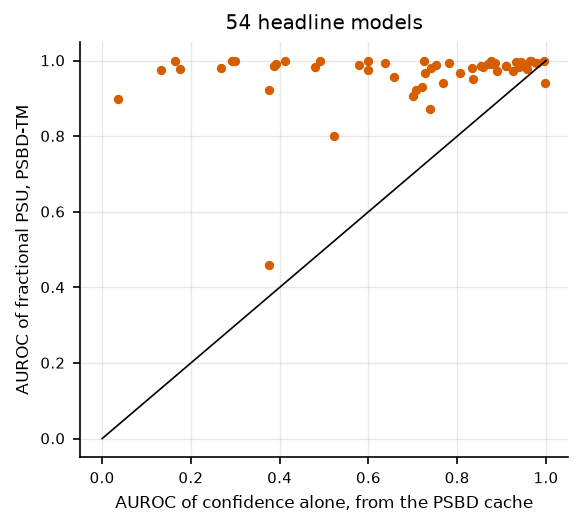


Each point is 1 headline model, with the confidence AUROC on the horizontal axis and the fractional PSU AUROC on the vertical axis. Every point above the diagonal is a model where the perturbed passes add separation that confidence alone does not have. Fractional PSU is above confidence on 53 of 54 models, with means of 0.963 against 0.688. The measurement rules out PSU being confidence alone on this population. It does not say why the passes help, which `experiments/why_token_masking_works/` measures. It also does not rule out that confidence carries part of the signal, since confidence alone exceeds 0.9 AUROC on 14 models.

The cross-check against the detector record agrees exactly on 54 of 54 models and disagrees on 0. Run on `vit_cifar10_sig_0_1`, which the clean-accuracy bar leaves out of the headline population, the same check disagrees, by 0.273 AUROC. The next cell takes that disagreement apart, since the model was in the headline until the panel moved to the success bar.


In [17]:
measured["confidence detector record"] = [reading(folder, "confidence") for folder in measured.index]
figure, axis = plt.subplots(figsize=(4.2, 3.6))
axis.scatter(measured["confidence"], measured["fractional PSU"], s=12, color=TRIGGERED_COLOR)
axis.plot([0, 1], [0, 1], color="black", linewidth=0.8)
axis.set_xlabel("AUROC of confidence alone, from the PSBD cache")
axis.set_ylabel("AUROC of fractional PSU, PSBD-TM")
axis.set_title(f"{len(measured)} headline models")
plt.show()

gap = (measured["confidence"] - measured["confidence detector record"]).abs()
disagreeing = list(gap[gap > 1e-3].index)
# The SIG model is out of the headline population (it fails the clean-accuracy
# bar), and it is the 1 model whose cache and detector record disagree, so it is
# measured on its own for the next cell.
sig_scores = measure_scores(SIG)
sig_gap = abs(sig_scores["confidence"] - reading(SIG, "confidence"))
say(f'''
Each point is 1 headline model, with the confidence AUROC on the horizontal axis and the fractional PSU AUROC on the vertical axis. Every point above the diagonal is a model where the perturbed passes add separation that confidence alone does not have. Fractional PSU is above confidence on {int((measured["fractional PSU"] > measured["confidence"]).sum())} of {len(measured)} models, with means of {measured["fractional PSU"].mean():.3f} against {measured["confidence"].mean():.3f}. The measurement rules out PSU being confidence alone on this population. It does not say why the passes help, which `experiments/why_token_masking_works/` measures. It also does not rule out that confidence carries part of the signal, since confidence alone exceeds 0.9 AUROC on {int((measured["confidence"] > 0.9).sum())} models.

The cross-check against the detector record agrees exactly on {len(measured) - len(disagreeing)} of {len(measured)} models and disagrees on {len(disagreeing)}{": " + word_list(list(f"`{folder}`" for folder in disagreeing)) if disagreeing else ""}. Run on `{SIG}`, which the clean-accuracy bar leaves out of the headline population, the same check {"disagrees" if sig_gap > 1e-3 else "agrees"}, by {sig_gap:.3f} AUROC. The next cell takes that disagreement apart, since the model was in the headline until the panel moved to the success bar.
''')

In [18]:
sig_dir = f"{RESULTS}/{SIG}"
headline_floor = min(reading(folder, "PSBD-TM") for folder in PANEL)
sig_drop = models.set_index("folder_name").loc[SIG, "clean_accuracy_drop"]
sig_run = read_run_provenance(f"{sig_dir}/psbd", TM)
with open(f"{sig_dir}/detectors/confidence_metrics.json") as handle:
    sig_record = json.load(handle)
split_gaps = {}
for split in SPLITS:
    probs, _, _ = load_baseline(baseline_path(f"{sig_dir}/psbd", split))
    recorded = torch.load(f"{sig_dir}/detectors/confidence_scores_{split}.pt")
    split_gaps[split] = float((-probs.max(dim=1).values.float() - recorded).abs().max())
baseline_written = datetime.datetime.fromtimestamp(os.path.getmtime(baseline_path(f"{sig_dir}/psbd", "backdoor")), datetime.timezone.utc)
checkpoint_written = datetime.datetime.fromtimestamp(os.path.getmtime(f"checkpoints/{SIG}/attack_result.pt"), datetime.timezone.utc)

say(f'''
On `{SIG}` the per-image confidence from the PSBD cache and from the detector record differ by at most {split_gaps["validation"]:.3f} on validation, {split_gaps["clean"]:.3f} on clean and {split_gaps["backdoor"]:.3f} on the triggered split. The confidence AUROC reads {sig_scores["confidence"]:.3f} from the cache and {reading(SIG, "confidence"):.3f} from the record. The record states `manifest_matches_psbd_cache` = {sig_record["provenance"]["split"]["manifest_matches_psbd_cache"]} and the same {sig_record["provenance"]["split"]["n_backdoor"]} triggered rows, and the checkpoint was written on {checkpoint_written:%Y-%m-%d}, before both runs, so the 2 runs scored the same model on the same images and stamped different SIG triggers onto them. The PSBD baseline of the triggered split was written on {baseline_written:%Y-%m-%d}, and the PSBD-TM sweep records commit `{sig_run["git_commit"][:7]}`. The detector records were scored on {sig_record["provenance"]["scored_at"][:10]} at commit `{sig_record["provenance"]["git_commit"][:7]}`. This is the model on which PSBD-TM reads {reading(SIG, "PSBD-TM"):.3f}, {"below" if reading(SIG, "PSBD-TM") < headline_floor else "above"} the lowest reading of the headline population ({headline_floor:.3f}), so that reading and the competitor readings on the same model are taken on different triggered images until the SIG cache is regenerated. The model is out of every mean anyway: its clean accuracy is {sig_drop:+.3f} against the benign model, past both success bars. The SIG trigger amplitude of models trained before the current `attacks/sig.py` is under audit, and `all_numbers.csv` keeps every SIG row with the note "{models.set_index("folder_name").loc[SIG, "audit_note"]}". The next question is at which rate to run the passes, since every number so far was read at a rate chosen by a rule not yet shown.
''')


On `vit_cifar10_sig_0_1` the per-image confidence from the PSBD cache and from the detector record differ by at most 0.000 on validation, 0.000 on clean and 0.600 on the triggered split. The confidence AUROC reads 0.593 from the cache and 0.866 from the record. The record states `manifest_matches_psbd_cache` = True and the same 7200 triggered rows, and the checkpoint was written on 2026-07-05, before both runs, so the 2 runs scored the same model on the same images and stamped different SIG triggers onto them. The PSBD baseline of the triggered split was written on 2026-08-13, and the PSBD-TM sweep records commit `5a58a82`. The detector records were scored on 2026-09-11 at commit `63b334d`. This is the model on which PSBD-TM reads 0.418, below the lowest reading of the headline population (0.459), so that reading and the competitor readings on the same model are taken on different triggered images until the SIG cache is regenerated. The model is out of every mean anyway: its clean accuracy is -0.106 against the benign model, past both success bars. The SIG trigger amplitude of models trained before the current `attacks/sig.py` is under audit, and `all_numbers.csv` keeps every SIG row with the note "SIG trigger amplitude under audit: caches may mix the trained and the current amplitude". The next question is at which rate to run the passes, since every number so far was read at a rate chosen by a rule not yet shown.


In [19]:
say(f'''
## The adaptive and matched rate rules

Every placement is swept over a ladder of rates, and 1 rate has to be chosen per model and placement without looking at triggered images, since a defender does not have them. Li et al. choose the dropout rate where the shift ratio of clean validation data "approaches a high value" and where the gap between the shift ratio of the training set and of clean validation is largest. Only the first half transfers to this setup. The second half carries signal in the paper because their scored pool is the poisoned training set, and ours is a clean test pool where that gap is noise around 0.

The **adaptive rule** (`select_rate_adaptively`) takes the smallest swept rate whose clean validation shift ratio reaches $\\sigma^\\ast$ = `ADAPTIVE_SHIFT_TARGET` = {ADAPTIVE_SHIFT_TARGET}, the value Li et al. report. The smallest such rate is chosen because a larger rate destroys more clean evidence for no gain in the criterion the defender can see. When no rate on the ladder reaches the target the rule returns nothing, the model gets no adaptive reading at that placement, and `scripts/all_numbers.py` writes a row with status `shift_target_unreached` rather than guessing a rate. This is the deployable rule, and every headline number uses it.

The **matched rule** (`select_rate_at_matched_shift`) takes the swept rate whose clean validation shift ratio sits nearest $\\sigma^\\ast$ = `PLACEMENT_MATCH_TARGET` = {PLACEMENT_MATCH_TARGET}, ties going to the smaller rate. It exists to compare placements at the same measured disturbance, and it uses a lower target than the adaptive rule because at the higher target the destructive placements have already saturated and the ranking between placements compresses (the reasoning is in the comments of `defenses/decision.py`).
''')


## The adaptive and matched rate rules

Every placement is swept over a ladder of rates, and 1 rate has to be chosen per model and placement without looking at triggered images, since a defender does not have them. Li et al. choose the dropout rate where the shift ratio of clean validation data "approaches a high value" and where the gap between the shift ratio of the training set and of clean validation is largest. Only the first half transfers to this setup. The second half carries signal in the paper because their scored pool is the poisoned training set, and ours is a clean test pool where that gap is noise around 0.

The **adaptive rule** (`select_rate_adaptively`) takes the smallest swept rate whose clean validation shift ratio reaches $\sigma^\ast$ = `ADAPTIVE_SHIFT_TARGET` = 0.8, the value Li et al. report. The smallest such rate is chosen because a larger rate destroys more clean evidence for no gain in the criterion the defender can see. When no rate on the ladder reaches the target the rule returns nothing, the model gets no adaptive reading at that placement, and `scripts/all_numbers.py` writes a row with status `shift_target_unreached` rather than guessing a rate. This is the deployable rule, and every headline number uses it.

The **matched rule** (`select_rate_at_matched_shift`) takes the swept rate whose clean validation shift ratio sits nearest $\sigma^\ast$ = `PLACEMENT_MATCH_TARGET` = 0.6, ties going to the smaller rate. It exists to compare placements at the same measured disturbance, and it uses a lower target than the adaptive rule because at the higher target the destructive placements have already saturated and the ranking between placements compresses (the reasoning is in the comments of `defenses/decision.py`).


$$
p_{adapt} = \min\{\, p \in \mathcal{P} : \sigma_p(D_{val}) \ge \sigma^\ast \,\}, \qquad
p_{match} = \arg\min_{p \in \mathcal{P}} \big|\sigma_p(D_{val}) - \sigma^\ast\big|
$$

| symbol | meaning |
|---|---|
| $\mathcal{P}$ | the swept rate ladder of the placement |
| $\sigma_p(D_{val})$ | the shift ratio of the clean validation images at rate $p$ |
| $\sigma^\ast$ | the target shift ratio, `ADAPTIVE_SHIFT_TARGET` or `PLACEMENT_MATCH_TARGET` |
| $p_{adapt}, p_{match}$ | the rates the 2 rules choose |

`cli.compare_detectors.psbd_rate` reads the chosen rate back out of `psbd_metrics.json` (`adaptive_rate` for the adaptive rule, the `matched_shift` entry of the matched target for the matched rule), and `psbd_values` returns that rate's `detection_psu_ratio` block. Every paper generator and `scripts/all_numbers.py` read PSBD through these 2 functions.

`defenses/decision.py`, `select_rate_adaptively`

```python
    reached = sorted(
        rate
        for rate, sigma in shift_by_rate.items()
        if sigma is not None and sigma >= target
    )
    smallest_reaching = reached[0] if reached else None
    return smallest_reaching
```

`defenses/decision.py`, `select_rate_at_matched_shift`

```python
    usable = {rate: value for rate, value in shift_by_rate.items() if value is not None}
    if not usable:
        return None

    closest = min(sorted(usable), key=lambda rate: abs(usable[rate] - target))
    return closest
```

`cli/compare.py`, `detectors_psbd_values`

```python
def detectors_psbd_values(
    report: dict | None, placement: str, rule: str
) -> dict | None:
    """Every quantile's fractional-PSU report at the rate the rule picked, or None."""
    if report is None:
        return None
    block = report.get("placements", {}).get(placement)
    if block is None:
        return None
    rate = detectors_psbd_rate(block, rule)
    if rate is None:
        return None
    for row in block.get("rates", []):
        if row.get("rate") == rate:
            values = dict(row.get("detection_psu_ratio", {}))
            values["_rate"] = rate
            values["_n_backdoor"] = row.get("n_samples", {}).get("backdoor")
            return values
    return None
```

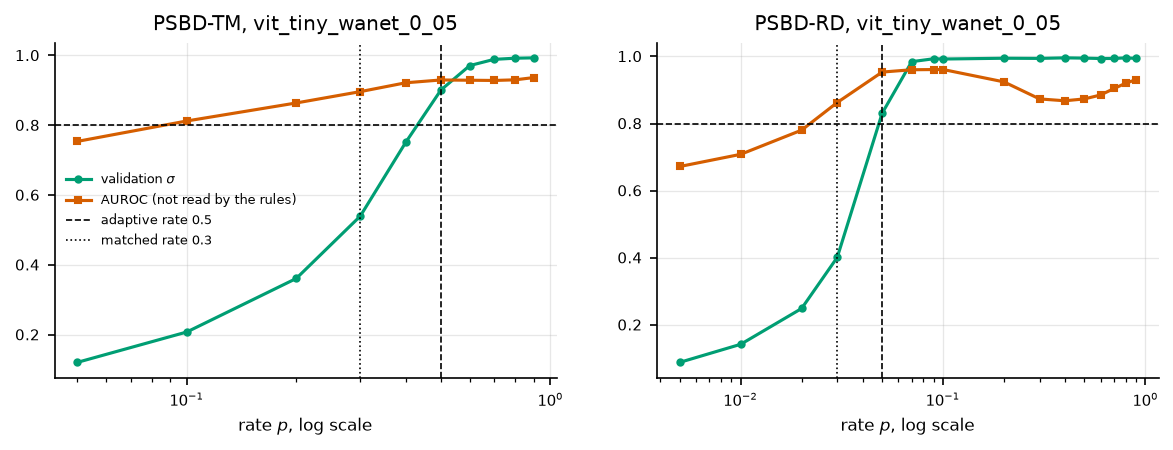

defense,PSBD-RD,PSBD-TM
0.05,13,0
0.07,19,0
0.09,20,0
0.10,2,0
0.30,0,2
0.40,0,2
0.50,0,31
0.60,0,10
0.70,0,6
0.80,0,3



The 2 panels show, for PSBD-TM on the left and PSBD-RD on the right, the clean validation shift ratio (green) and the AUROC (orange) against the rate on a log axis, with the dashed vertical line at the adaptive rate and the dotted one at the matched rate. The reader should check that the dashed line sits at the first green point at or above 0.8, and notice that PSBD-RD reaches it at rate 0.05 against 0.5 for PSBD-TM, because dropout on the residual stream acts on every coordinate in every block at once. PSBD-RD's matched rate shows what a coarse ladder does to the matched rule: rate 0.03 gives a shift ratio of 0.40 and rate 0.05 gives 0.83, and the rule takes 0.03, the nearer of the 2 to 0.6. The AUROC curve is drawn to show that the rule is not the rate a label-reading oracle would pick. The table counts which rate the adaptive rule chose across the 54 headline models: PSBD-TM most often chose 0.5 and PSBD-RD 0.09. What the rule guarantees is a fixed clean disturbance, not a good detection rate. The next question is how a score at that rate becomes a yes or no decision.


In [20]:
show_source(select_rate_adaptively, start=-7)
show_source(select_rate_at_matched_shift, start=-6)
show_source(psbd_values)

chosen_rates = {}
figure, axes = plt.subplots(1, 2, figsize=(9.5, 2.9))
for axis, placement, name in ((axes[0], TM, "PSBD-TM"), (axes[1], RD, "PSBD-RD")):
    block = report["placements"][placement]
    rates = [row["rate"] for row in block["rates"]]
    sigma = {row["rate"]: row["shift_ratio"]["validation"] for row in block["rates"]}
    auroc = [row["detection_psu_ratio"][f"q{HEADLINE_QUANTILE:.2f}"]["auroc"] for row in block["rates"]]
    adaptive = select_rate_adaptively(sigma)
    matched = select_rate_at_matched_shift(sigma, PLACEMENT_MATCH_TARGET)
    assert adaptive == block["adaptive_rate"] == reading(EXAMPLE, name, "rate")
    assert matched == block["matched_shift"][shift_key(PLACEMENT_MATCH_TARGET)]["rate"] == reading(EXAMPLE, f"{name} {MATCHED_SUFFIX}", "rate")
    chosen_rates[name] = {"adaptive": adaptive, "matched": matched, "sigma": sigma}
    axis.plot(rates, [sigma[r] for r in rates], marker="o", markersize=3, color=VALIDATION_COLOR, label=r"validation $\sigma$")
    axis.plot(rates, auroc, marker="s", markersize=3, color=TRIGGERED_COLOR, label="AUROC (not read by the rules)")
    axis.axhline(ADAPTIVE_SHIFT_TARGET, color="black", linewidth=0.8, linestyle="--")
    axis.axvline(adaptive, color="black", linewidth=0.8, linestyle="--", label=f"adaptive rate {adaptive:g}")
    axis.axvline(matched, color="black", linewidth=0.8, linestyle=":", label=f"matched rate {matched:g}")
    axis.set_xscale("log")
    axis.set_xlabel("rate $p$, log scale")
    axis.set_title(f"{name}, {EXAMPLE}")
axes[0].legend(fontsize=6)
plt.show()

panel_rates = vit[vit.folder_name.isin(PANEL) & vit.defense.isin(["PSBD-TM", "PSBD-RD"])].pivot(index="folder_name", columns="defense", values="rate")
rate_counts = panel_rates.apply(lambda column: column.value_counts()).fillna(0).astype(int)
display(rate_counts)

rd_rates = chosen_rates["PSBD-RD"]
rd_below = max(rate for rate in rd_rates["sigma"] if rate < rd_rates["adaptive"])
say(f'''
The 2 panels show, for PSBD-TM on the left and PSBD-RD on the right, the clean validation shift ratio (green) and the AUROC (orange) against the rate on a log axis, with the dashed vertical line at the adaptive rate and the dotted one at the matched rate. The reader should check that the dashed line sits at the first green point at or above {ADAPTIVE_SHIFT_TARGET}, and notice that PSBD-RD reaches it at rate {rd_rates["adaptive"]:g} against {chosen_rates["PSBD-TM"]["adaptive"]:g} for PSBD-TM, because dropout on the residual stream acts on every coordinate in every block at once. PSBD-RD's matched rate shows what a coarse ladder does to the matched rule: rate {rd_below:g} gives a shift ratio of {rd_rates["sigma"][rd_below]:.2f} and rate {rd_rates["adaptive"]:g} gives {rd_rates["sigma"][rd_rates["adaptive"]]:.2f}, and the rule takes {rd_rates["matched"]:g}, the nearer of the 2 to {PLACEMENT_MATCH_TARGET}. The AUROC curve is drawn to show that the rule is not the rate a label-reading oracle would pick. The table counts which rate the adaptive rule chose across the {len(PANEL)} headline models: PSBD-TM most often chose {panel_rates["PSBD-TM"].mode()[0]:g} and PSBD-RD {panel_rates["PSBD-RD"].mode()[0]:g}. What the rule guarantees is a fixed clean disturbance, not a good detection rate. The next question is how a score at that rate becomes a yes or no decision.
''')

In [21]:
say(f'''
## The quantile threshold, TPR and the realized FPR

An image is flagged as triggered when its score falls below a threshold $\\tau_q$, set at the $q$ quantile of the {PSBD_HELDOUT_SIZE} clean validation scores. The threshold reads clean data only, so the quantile is the false-positive budget the defender chooses: at $q$ = {BUDGETS[0]:.2f} about {BUDGETS[0]:.0%} of clean images are expected to be flagged. The quantile ladder is `PSBD_QUANTILES` = {PSBD_QUANTILES}. The paper reports TPR at the {BUDGETS[0]:.2f} and {BUDGETS[1]:.2f} budgets, the operating points a deployment could tolerate. The original PSBD uses the {HEADLINE_QUANTILE:.0%} quantile everywhere, so `HEADLINE_QUANTILE` = {HEADLINE_QUANTILE} is kept as the key the headline blocks are stored under, which keeps the numbers comparable with the published tables. AUROC does not depend on the threshold, so the AUROC stored in every quantile block of a record is the same number.

The realized FPR is measured on the paired clean test images and differs from $q$ for 2 reasons, sampling (a finite validation set) and population (the paired images exclude the target class, or keep only TaCT's source class). `defenses.decision.detection_report` computes all of these in 1 place for PSBD and every competitor alike.
''')


## The quantile threshold, TPR and the realized FPR

An image is flagged as triggered when its score falls below a threshold $\tau_q$, set at the $q$ quantile of the 2000 clean validation scores. The threshold reads clean data only, so the quantile is the false-positive budget the defender chooses: at $q$ = 0.10 about 10% of clean images are expected to be flagged. The quantile ladder is `PSBD_QUANTILES` = (0.01, 0.05, 0.1, 0.15, 0.2, 0.25). The paper reports TPR at the 0.10 and 0.20 budgets, the operating points a deployment could tolerate. The original PSBD uses the 25% quantile everywhere, so `HEADLINE_QUANTILE` = 0.25 is kept as the key the headline blocks are stored under, which keeps the numbers comparable with the published tables. AUROC does not depend on the threshold, so the AUROC stored in every quantile block of a record is the same number.

The realized FPR is measured on the paired clean test images and differs from $q$ for 2 reasons, sampling (a finite validation set) and population (the paired images exclude the target class, or keep only TaCT's source class). `defenses.decision.detection_report` computes all of these in 1 place for PSBD and every competitor alike.


$$
\tau_q = Q_q\big(\{\phi(x) : x \in D_{val}\}\big), \qquad
\mathrm{TPR}_q = \frac{1}{|D_{bd}|} \sum_{x \in D_{bd}} \mathbb{I}\big(\phi(x) < \tau_q\big), \qquad
\mathrm{FPR}_q = \frac{1}{|D_{cl}|} \sum_{x \in D_{cl}} \mathbb{I}\big(\phi(x) < \tau_q\big)
$$

| symbol | meaning |
|---|---|
| $\phi(x)$ | the score of image $x$, fractional PSU for PSBD |
| $Q_q$ | the empirical $q$ quantile with numpy's linear interpolation (`threshold_at_quantile`) |
| $q$ | the budget, a value on `PSBD_QUANTILES` |
| $D_{val}$ | the clean validation images |
| $D_{bd}$ | the triggered images of the backdoor split |
| $D_{cl}$ | the paired clean copies of those same images |
| $\tau_q$ | the threshold, strictly below which an image is flagged |
| $\mathrm{TPR}_q$ | the share of triggered images flagged, the true positive rate |
| $\mathrm{FPR}_q$ | the share of paired clean images flagged, the realized false positive rate |

`defenses/decision.py`, `threshold_at_quantile`

```python
    threshold = float(np.quantile(validation_psu.float().numpy(), quantile))
    return threshold
```

`defenses/decision.py`, `detection_report`

```python
    auroc = (
        float(roc_auc_score(labels, scores))
        if len(set(labels.tolist())) > 1
        else float("nan")
    )
    auprc = (
        float(average_precision_score(labels, scores))
        if len(set(labels.tolist())) > 1
        else float("nan")
    )
    positive_share = float(labels.mean()) if len(labels) else float("nan")
    auroc_is_defined = not math.isnan(auroc)
```

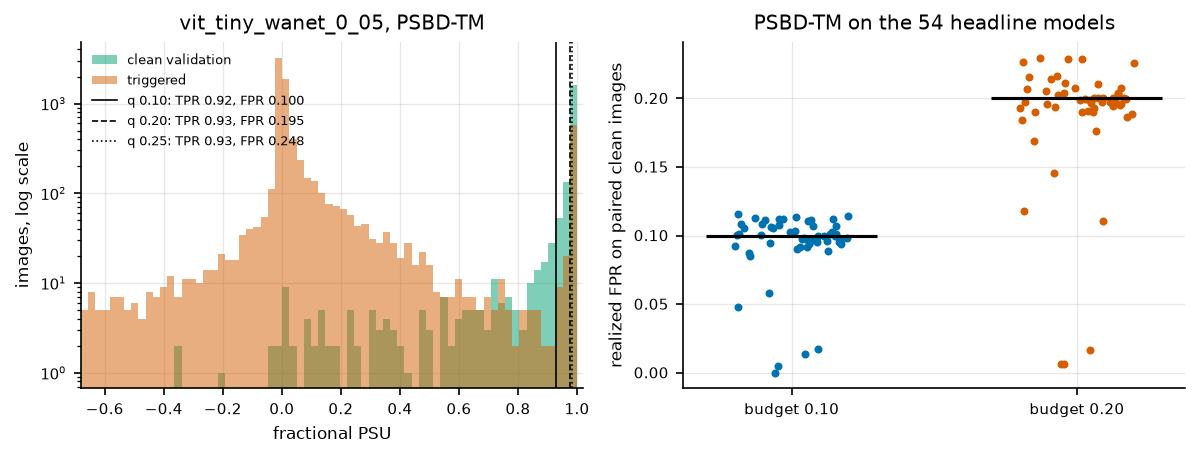


The left panel is the example. The green histogram is the fractional PSU of the validation images and the orange one the triggered images (cut at their 0.5th percentile, since a few triggered images reach -3.9, where the passes raised the probability). The vertical lines are the thresholds at the 0.10, 0.20 and 0.25 quantiles, each labeled with the TPR and realized FPR it produces. The reader should see that the thresholds sit in the left tail of the validation scores and that most triggered images fall below them. The right panel shows, for each headline model, the realized FPR at the 2 budgets (points, jittered sideways) against the budget itself (black tick). At the 0.10 budget the realized FPR has a mean of 0.093 and a median of 0.100, and at the 0.20 budget 0.186 and 0.199. The 3 lowest points at the 0.10 budget are `vit_gtsrb_tact_0_05` (0.000), `vit_cifar10_tact_0_05` (0.005) and `vit_cifar10_tact_0_01` (0.014), attack tact, whose paired images all come from 1 source class that masking barely moves, the case the section after next takes apart. TPR is a statement at 1 threshold, so the next question is the threshold-free summary and its direction.


In [22]:
show_source(threshold_at_quantile, start=-2)
show_source(detection_report, start=36, stop=48)

validation_scores = fractional_psu(example["validation"])
example_reports = {}
figure, (histogram_axis, realized_axis) = plt.subplots(1, 2, figsize=(9.5, 3.0))
# cut at the 0.5th percentile of the triggered scores, whose long negative tail
# (passes that raise the probability) would otherwise squeeze the bulk
histogram_low = float(min(np.quantile(triggered["fractional"].numpy(), 0.005), validation_scores.min()))
bins = np.linspace(histogram_low, 1.0, 70)
histogram_axis.hist(validation_scores.numpy(), bins=bins, color=VALIDATION_COLOR, alpha=0.5, label="clean validation")
histogram_axis.hist(triggered["fractional"].numpy(), bins=bins, color=TRIGGERED_COLOR, alpha=0.5, label="triggered")
for quantile, style in ((BUDGETS[0], "-"), (BUDGETS[1], "--"), (HEADLINE_QUANTILE, ":")):
    example_reports[quantile] = detection_report(validation_scores, paired_clean["fractional"], triggered["fractional"], quantile)
    assert abs(example_reports[quantile]["tpr"] - reading(EXAMPLE, "PSBD-TM", f"tpr_q{quantile:.2f}")) < 1e-6
    assert abs(example_reports[quantile]["fpr"] - reading(EXAMPLE, "PSBD-TM", f"fpr_q{quantile:.2f}")) < 1e-6
    histogram_axis.axvline(example_reports[quantile]["threshold"], color="black", linestyle=style, linewidth=0.8, label=f"q {quantile:.2f}: TPR {example_reports[quantile]['tpr']:.2f}, FPR {example_reports[quantile]['fpr']:.3f}")
histogram_axis.set_yscale("log")
histogram_axis.set_xlim(histogram_low, 1.02)
histogram_axis.set_xlabel("fractional PSU")
histogram_axis.set_ylabel("images, log scale")
histogram_axis.set_title(f"{EXAMPLE}, PSBD-TM")
histogram_axis.legend(fontsize=6)

panel_rows = vit[vit.folder_name.isin(PANEL) & (vit.defense == "PSBD-TM")].set_index("folder_name")
jitter = np.random.default_rng(0).uniform(-0.02, 0.02, len(panel_rows))
for quantile, color in zip(BUDGETS, (CLEAN_COLOR, TRIGGERED_COLOR)):
    realized_axis.scatter(quantile + jitter, panel_rows[f"fpr_q{quantile:.2f}"], s=8, color=color)
    realized_axis.hlines(quantile, quantile - 0.03, quantile + 0.03, color="black")
realized_axis.set_xticks(list(BUDGETS), [f"budget {quantile:.2f}" for quantile in BUDGETS])
realized_axis.set_ylabel("realized FPR on paired clean images")
realized_axis.set_title(f"PSBD-TM on the {len(panel_rows)} headline models")
plt.show()

lowest = panel_rows[f"fpr_q{BUDGETS[0]:.2f}"].nsmallest(3)
lowest_attacks = sorted(set(models.set_index("folder_name").loc[lowest.index, "attack"]))
say(f'''
The left panel is the example. The green histogram is the fractional PSU of the validation images and the orange one the triggered images (cut at their 0.5th percentile, since a few triggered images reach {float(triggered["fractional"].min()):.1f}, where the passes raised the probability). The vertical lines are the thresholds at the {BUDGETS[0]:.2f}, {BUDGETS[1]:.2f} and {HEADLINE_QUANTILE:.2f} quantiles, each labeled with the TPR and realized FPR it produces. The reader should see that the thresholds sit in the left tail of the validation scores and that most triggered images fall below them. The right panel shows, for each headline model, the realized FPR at the 2 budgets (points, jittered sideways) against the budget itself (black tick). At the {BUDGETS[0]:.2f} budget the realized FPR has a mean of {panel_rows[f"fpr_q{BUDGETS[0]:.2f}"].mean():.3f} and a median of {panel_rows[f"fpr_q{BUDGETS[0]:.2f}"].median():.3f}, and at the {BUDGETS[1]:.2f} budget {panel_rows[f"fpr_q{BUDGETS[1]:.2f}"].mean():.3f} and {panel_rows[f"fpr_q{BUDGETS[1]:.2f}"].median():.3f}. The 3 lowest points at the {BUDGETS[0]:.2f} budget are {word_list(list(f"`{folder}` ({value:.3f})" for folder, value in lowest.items()))}, attack {word_list(list(lowest_attacks))}, whose paired images all come from 1 source class that masking barely moves, the case the section after next takes apart. TPR is a statement at 1 threshold, so the next question is the threshold-free summary and its direction.
''')

## AUROC and its direction

AUROC is the area under the ROC curve, equivalently the probability that a random triggered image scores below a random paired clean image, with ties counted as half,

$$
\mathrm{AUROC} = \frac{1}{|D_{bd}|\,|D_{cl}|} \sum_{x \in D_{bd}} \sum_{x' \in D_{cl}} \Big( \mathbb{I}\big(\phi(x) < \phi(x')\big) + \tfrac{1}{2}\, \mathbb{I}\big(\phi(x) = \phi(x')\big) \Big)
$$

with the symbols of the previous section. `detection_report` computes it with scikit-learn's `roc_auc_score` on the negated scores, because that function ranks a higher score as more positive and here a lower score is the poisoned evidence. The AUROC is **one-sided**. The direction (low means poisoned) is fixed before the data is seen, so a value below 0.5 means the defense ordered the 2 classes the wrong way round on that model, and it stays below 0.5 in every mean. I rejected the two-sided form $\max(A, 1 - A)$, because choosing the side needs the labels a defender does not have, and it would turn every inverted model into a success. The record keeps `auroc_two_sided` as a diagnostic field that no table reads, and it stores a `direction` of `inverted` below 0.5.

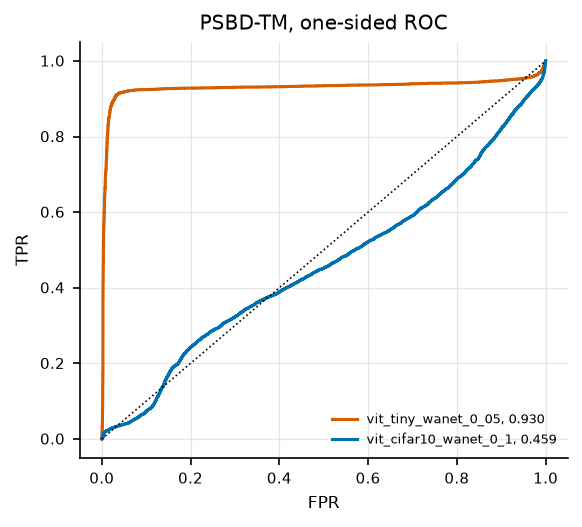


The figure plots TPR against FPR as the threshold sweeps over every score, for the example (orange) and for the 1 headline models where PSBD-TM reads below 0.5: `vit_cifar10_wanet_0_1` (wanet at 10% poisoning on cifar10). The reader should see the example's curve hug the top left corner and the others run under the dotted diagonal, where triggered images are less robust to token masking than their clean copies. Those values enter every mean as they are, and the paper's macro for this count, `HeadlineInversions`, reads 1. `vit_cifar10_sig_0_1` carries the caveat of the confidence section, a PSBD cache whose triggered images differ from the detector records' triggered images. AUROC compares triggered images with their own clean copies and says nothing about where a validation threshold falls, which the next section shows can matter a great deal.


In [23]:
inverted = sorted(folder for folder in PANEL if reading(folder, "PSBD-TM") < 0.5)

figure, axis = plt.subplots(figsize=(4.2, 3.6))
for folder, color in ((EXAMPLE, TRIGGERED_COLOR), *zip(inverted, ("#0072B2", "#009E73", "#CC79A7", "#E69F00"))):
    data = load_rate(folder, TM, reading(folder, "PSBD-TM", "rate"))
    clean = pair_clean_to_backdoor(fractional_psu(data["clean"]), data["manifest"])
    backdoor = fractional_psu(data["backdoor"])
    labels = np.r_[np.zeros(len(clean)), np.ones(len(backdoor))]
    false_positive, true_positive, _ = roc_curve(labels, np.r_[-clean.numpy(), -backdoor.numpy()])
    axis.plot(false_positive, true_positive, color=color, label=f"{folder}, {one_sided_auroc(clean, backdoor):.3f}")
axis.plot([0, 1], [0, 1], color="black", linewidth=0.8, linestyle=":")
axis.set_xlabel("FPR")
axis.set_ylabel("TPR")
axis.set_title("PSBD-TM, one-sided ROC")
axis.legend(fontsize=6)
plt.show()

say(f'''
The figure plots TPR against FPR as the threshold sweeps over every score, for the example (orange) and for the {len(inverted)} headline models where PSBD-TM reads below 0.5: {word_list(list(model_words(folder) for folder in inverted))}. The reader should see the example's curve hug the top left corner and the others run under the dotted diagonal, where triggered images are less robust to token masking than their clean copies. Those values enter every mean as they are, and the paper's macro for this count, `HeadlineInversions`, reads {macro("HeadlineInversions")}. `{SIG}` carries the caveat of the confidence section, a PSBD cache whose triggered images differ from the detector records' triggered images. AUROC compares triggered images with their own clean copies and says nothing about where a validation threshold falls, which the next section shows can matter a great deal.
''')

In [24]:
tact = load_rate(TACT, TM, reading(TACT, "PSBD-TM", "rate"))
sources = source_classes_of("checkpoints", {"folder_name": TACT, "attack": "tact"})
tact_validation = fractional_psu(tact["validation"])  # (n_validation,)
validation_labels = tact["validation"]["loader_labels"]  # (n_validation,)
in_source = sum(validation_labels == source for source in sources).bool()  # (n_validation,)
tact_clean = pair_clean_to_backdoor(fractional_psu(tact["clean"]), tact["manifest"])
tact_backdoor = fractional_psu(tact["backdoor"])
tact_report = detection_report(tact_validation, tact_clean, tact_backdoor, BUDGETS[0])
assert abs(tact_report["auroc"] - reading(TACT, "PSBD-TM")) < 1e-9
assert abs(tact_report["tpr"] - reading(TACT, "PSBD-TM", f"tpr_q{BUDGETS[0]:.2f}")) < 1e-9
tact_classes = DATASET_REGISTRY[models.set_index("folder_name").loc[TACT, "dataset"]].num_classes

say(f'''
## High AUROC with a low TPR

{model_words(TACT)} reads an AUROC of {tact_report["auroc"]:.3f} for PSBD-TM and a TPR of {tact_report["tpr"]:.3f} at the {BUDGETS[0]:.2f} budget, and a reader seeing both in 1 table may suspect an error. The 2 numbers answer different questions about different populations. TaCT is a source-specific attack: only images of its source classes (here {list(sources)}) are supposed to flip to the target when triggered, so its backdoor split holds {len(tact_backdoor)} source-class images only. The paired clean images are source-class images too. AUROC compares those 2 sets. The threshold, in contrast, is a quantile of validation scores over all {tact_classes} classes. If the source class is unusually robust to masking, the triggered source images can sit below every clean source image and still above the low tail of all classes.
''')


## High AUROC with a low TPR

`vit_cifar10_tact_0_01` (tact at 1% poisoning on cifar10) reads an AUROC of 0.979 for PSBD-TM and a TPR of 0.005 at the 0.10 budget, and a reader seeing both in 1 table may suspect an error. The 2 numbers answer different questions about different populations. TaCT is a source-specific attack: only images of its source classes (here [1]) are supposed to flip to the target when triggered, so its backdoor split holds 796 source-class images only. The paired clean images are source-class images too. AUROC compares those 2 sets. The threshold, in contrast, is a quantile of validation scores over all 10 classes. If the source class is unusually robust to masking, the triggered source images can sit below every clean source image and still above the low tail of all classes.


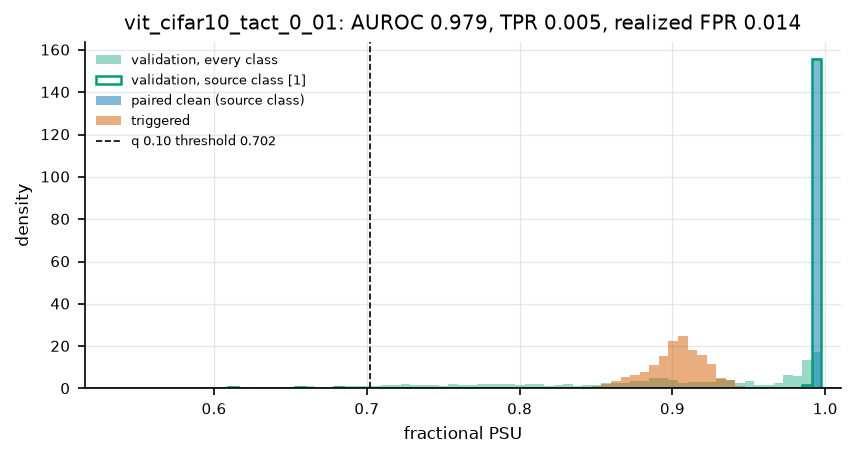


The horizontal axis is fractional PSU, cut at the 1st percentile of the validation scores so the bulk is visible. The vertical axis is density, so the 4 histograms are comparable despite different sizes. The reader should look at 3 positions. The paired clean source images (blue) and the validation images of the source class (green outline) pile up near 1, with medians of 0.995 and 0.995, so masking barely moves this model's predictions on the source class. The triggered images (orange) sit to the left of them, with a median of 0.904, which gives the AUROC of 0.979. The dashed threshold at 0.702, set by all classes, sits far to the left of the orange mass. 54% of all validation images score below the median triggered image, which gives the TPR of 0.005. Neither number is wrong. AUROC with pairing is a clean test of separation on 1 model, while TPR at a validation quantile is what a deployment screening all classes would see. Every table reports both for that reason. The next section explains how the ledger decides which models a mean may span.


In [25]:
figure, axis = plt.subplots(figsize=(6.5, 3.0))
low_edge = float(np.quantile(tact_validation.numpy(), 0.01))
bins = np.linspace(low_edge, 1.01, 80)
axis.hist(tact_validation.numpy(), bins=bins, density=True, color=VALIDATION_COLOR, alpha=0.4, label="validation, every class")
axis.hist(tact_validation[in_source].numpy(), bins=bins, density=True, histtype="step", color=VALIDATION_COLOR, linewidth=1.2, label=f"validation, source class {list(sources)}")
axis.hist(tact_clean.numpy(), bins=bins, density=True, color=CLEAN_COLOR, alpha=0.5, label="paired clean (source class)")
axis.hist(tact_backdoor.numpy(), bins=bins, density=True, color=TRIGGERED_COLOR, alpha=0.5, label="triggered")
axis.axvline(tact_report["threshold"], color="black", linestyle="--", linewidth=0.8, label=f"q {BUDGETS[0]:.2f} threshold {tact_report['threshold']:.3f}")
axis.set_xlim(low_edge, 1.01)
axis.set_xlabel("fractional PSU")
axis.set_ylabel("density")
axis.set_title(f"{TACT}: AUROC {tact_report['auroc']:.3f}, TPR {tact_report['tpr']:.3f}, realized FPR {tact_report['fpr']:.3f}")
axis.legend(fontsize=6)
plt.show()

share_below = float((tact_validation < float(tact_backdoor.median())).float().mean())
say(f'''
The horizontal axis is fractional PSU, cut at the 1st percentile of the validation scores so the bulk is visible. The vertical axis is density, so the 4 histograms are comparable despite different sizes. The reader should look at 3 positions. The paired clean source images (blue) and the validation images of the source class (green outline) pile up near 1, with medians of {float(tact_clean.median()):.3f} and {float(tact_validation[in_source].median()):.3f}, so masking barely moves this model's predictions on the source class. The triggered images (orange) sit to the left of them, with a median of {float(tact_backdoor.median()):.3f}, which gives the AUROC of {tact_report["auroc"]:.3f}. The dashed threshold at {tact_report["threshold"]:.3f}, set by all classes, sits far to the left of the orange mass. {share_below:.0%} of all validation images score below the median triggered image, which gives the TPR of {tact_report["tpr"]:.3f}. Neither number is wrong. AUROC with pairing is a clean test of separation on 1 model, while TPR at a validation quantile is what a deployment screening all classes would see. Every table reports both for that reason. The next section explains how the ledger decides which models a mean may span.
''')

In [26]:
panel_models = models[(models.architecture == "vit") & models.in_panel]
say(f'''
## The success bars and the panel

A detection number on a model whose attack never implanted is meaningless, since there is no backdoor to detect, so every mean spans only models whose backdoor is real. `scripts/coverage_ledger.py` decides this per model and writes the verdicts into `results/coverage/coverage.json`. The ViT **panel** is every checkpoint the declaration `configs/psbd_basis.json` selects: architecture `{declaration["panel"]["architecture"]}`, datasets {declaration["panel"]["datasets"]}, label modes {declaration["panel"]["label_modes"]}, poison rates {declaration["panel"]["poison_rates"]}, the canonical variant of each attack and no experiment tags. That is {len(panel_models)} models. Each gets an `asr_class`, applied in this order.

- `clears` when its ASR is at least `asr_bar` = {declaration["asr_bar"]}, `below_bar` otherwise, `unmeasured` when no ASR was recorded. The bar keeps weak implants out, since a model that sends only part of its triggered images to the target is only partly backdoored (`docs/attack-strength-and-implantation.md`).
- `diverged` overrides it when the clean accuracy is below `DIVERGENCE_FRACTION` = {DIVERGENCE_FRACTION} of the benign reference. A model that collapsed to predicting 1 class sends every triggered image to that class and reads a high ASR for a reason that has nothing to do with a backdoor.
- `source_mapped` overrides it when the model's clean accuracy on the source classes of a source-specific attack (TaCT) is below `SOURCE_MAPPED_ACCURACY` = {SOURCE_MAPPED_ACCURACY}. When every source image was poisoned in training, the model learns to send the whole class to the target with no trigger, and the ASR, which reads triggered images only, cannot see that.

The **success bars** are 2 verdicts added beside `asr_class` without changing it, by `success_verdicts`. $\\Delta CA$ is the clean accuracy of the model minus the clean accuracy of the benign model trained on the same dataset with the same recipe, negative when the attack cost accuracy. `successful_2pt`, the headline success definition, requires `clears` and $\\Delta CA \\ge$ `clean_accuracy_drop_bar_headline` = {declaration["clean_accuracy_drop_bar_headline"]}. `successful_5pt` requires `clears` and $\\Delta CA \\ge$ `clean_accuracy_drop_bar` = {declaration["clean_accuracy_drop_bar"]}. A backdoor that costs noticeable clean accuracy is a backdoor a defender could spot by accuracy alone, which is why the user set the headline bar at the tighter value and asked every number to be given at the looser one as well. `asr_class` stays as it was, since it is the implantation count, and every result is computed over the `successful_2pt` models (`scripts.paper._common.clearing_cells`), with the second-bar macros read on the `successful_5pt` models.
''')
show_source(success_verdicts)
show_source(classify_by_asr)


## The success bars and the panel

A detection number on a model whose attack never implanted is meaningless, since there is no backdoor to detect, so every mean spans only models whose backdoor is real. `scripts/coverage_ledger.py` decides this per model and writes the verdicts into `results/coverage/coverage.json`. The ViT **panel** is every checkpoint the declaration `configs/psbd_basis.json` selects: architecture `vit`, datasets ['cifar10', 'cifar100', 'gtsrb', 'tiny'], label modes ['all_to_one', 'clean_label'], poison rates [0.01, 0.05, 0.1], the canonical variant of each attack and no experiment tags. That is 98 models. Each gets an `asr_class`, applied in this order.

- `clears` when its ASR is at least `asr_bar` = 0.85, `below_bar` otherwise, `unmeasured` when no ASR was recorded. The bar keeps weak implants out, since a model that sends only part of its triggered images to the target is only partly backdoored (`docs/attack-strength-and-implantation.md`).
- `diverged` overrides it when the clean accuracy is below `DIVERGENCE_FRACTION` = 0.5 of the benign reference. A model that collapsed to predicting 1 class sends every triggered image to that class and reads a high ASR for a reason that has nothing to do with a backdoor.
- `source_mapped` overrides it when the model's clean accuracy on the source classes of a source-specific attack (TaCT) is below `SOURCE_MAPPED_ACCURACY` = 0.5. When every source image was poisoned in training, the model learns to send the whole class to the target with no trigger, and the ASR, which reads triggered images only, cannot see that.

The **success bars** are 2 verdicts added beside `asr_class` without changing it, by `success_verdicts`. $\Delta CA$ is the clean accuracy of the model minus the clean accuracy of the benign model trained on the same dataset with the same recipe, negative when the attack cost accuracy. `successful_2pt`, the headline success definition, requires `clears` and $\Delta CA \ge$ `clean_accuracy_drop_bar_headline` = -0.02. `successful_5pt` requires `clears` and $\Delta CA \ge$ `clean_accuracy_drop_bar` = -0.05. A backdoor that costs noticeable clean accuracy is a backdoor a defender could spot by accuracy alone, which is why the user set the headline bar at the tighter value and asked every number to be given at the looser one as well. `asr_class` stays as it was, since it is the implantation count, and every result is computed over the `successful_2pt` models (`scripts.paper._common.clearing_cells`), with the second-bar macros read on the `successful_5pt` models.


`scripts/coverage_ledger.py`, `success_verdicts`

```python
def success_verdicts(cell: dict, declaration: dict) -> dict[str, bool]:
    """Whether a cell is a successful backdoor at each declared clean-accuracy bar.

    Reads the cell's final asr_class, so a diverged, source-mapped, unmeasured or
    below-bar cell never succeeds. A clearing cell succeeds at a bar when its
    clean accuracy minus the benign reference is at least that (negative) bar,
    and fails when the drop is unknown.
    """
    implanted = cell["asr_class"] == "clears"
    drop = cell["clean_accuracy_drop"]
    verdicts = {
        field: implanted and drop is not None and drop >= declaration[bar_key]
        for field, bar_key in SUCCESS_BARS.items()
    }
    return verdicts
```

`scripts/coverage_ledger.py`, `classify_by_asr`

```python
def classify_by_asr(cell: dict, asr_bar: float) -> str:
    """A cell's ASR class: "clears", "below_bar" or "unmeasured"."""
    if cell["asr"] is None:
        return "unmeasured"
    return "clears" if cell["asr"] >= asr_bar else "below_bar"
```

,asr,clean_accuracy,clean_accuracy_benign,clean_accuracy_drop,successful_2pt,successful_5pt
folder_name,,,,,,
vit_cifar10_sig_0_1,0.9007,0.8465,0.9526,-0.1061,False,False
vit_cifar10_wanet_0_05,0.9610,0.9134,0.9526,-0.0392,False,True
vit_gtsrb_wanet_0_1,0.9465,0.9578,0.9913,-0.0335,False,True


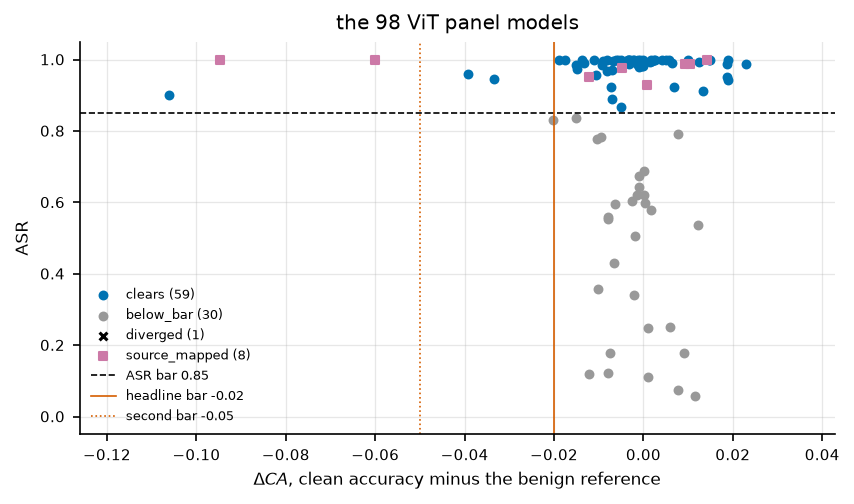


The ledger counts on the ViT panel are 59 `clears`, 30 `below_bar`, 8 `source_mapped` and 1 `diverged`. 56 models are successful at the headline bar against 58 at the second bar. Each point of the figure is 1 panel model, with the clean accuracy change on the horizontal axis and the ASR on the vertical axis, colored by `asr_class`. The diverged model ($\Delta CA$ -0.870) lies off the left edge, which is cut so the rest stay readable. A successful model sits above the dashed ASR line, right of the solid headline line (or the dotted second line for the looser bar) and in blue.

The reader should look at the blue points left of the lines: `vit_cifar10_sig_0_1` ($\Delta CA$ -0.106, fails both bars), `vit_cifar10_wanet_0_05` ($\Delta CA$ -0.039, fails only the headline bar) and `vit_gtsrb_wanet_0_1` ($\Delta CA$ -0.033, fails only the headline bar). These are the models the headline bar removes from every result. 2 successful models (`vit_gtsrb_lc_0_05_tl1_adv` and `vit_gtsrb_tact_0_01_cos`) have no PSBD-TM and PSBD-RD readings yet, which is why the headline population holds 54 models and not 56. The paper's `PanelCellsCached` macro reads 54, `PanelCellsSuccessful` reads 56 and `PanelCellsClearing`, the implantation count, reads 59. The next question is how 2 placements are compared over the models that remain.


In [27]:
clears = panel_models[panel_models.asr_class == "clears"]
failing = clears[~clears.successful_2pt.astype(bool) | ~clears.successful_5pt.astype(bool)]
display(failing[["folder_name", "asr", "clean_accuracy", "clean_accuracy_benign", "clean_accuracy_drop", "successful_2pt", "successful_5pt"]].set_index("folder_name").round(4))
successful = clears[clears.successful_2pt.astype(bool)]
unswept = sorted(set(successful.folder_name) - set(PANEL))
diverged = panel_models[panel_models.asr_class == "diverged"]

figure, axis = plt.subplots(figsize=(6.5, 3.4))
styles = {"clears": ("#0072B2", "o"), "below_bar": ("#999999", "o"), "diverged": ("#000000", "x"), "source_mapped": ("#CC79A7", "s")}
for asr_class, (color, marker) in styles.items():
    subset = panel_models[panel_models.asr_class == asr_class]
    axis.scatter(subset.clean_accuracy_drop, subset.asr, s=14, color=color, marker=marker, label=f"{asr_class} ({len(subset)})")
axis.axhline(declaration["asr_bar"], color="black", linewidth=0.8, linestyle="--", label=f"ASR bar {declaration['asr_bar']}")
axis.axvline(declaration["clean_accuracy_drop_bar_headline"], color="#D55E00", linewidth=0.8, label=f"headline bar {declaration['clean_accuracy_drop_bar_headline']}")
axis.axvline(declaration["clean_accuracy_drop_bar"], color="#D55E00", linewidth=0.8, linestyle=":", label=f"second bar {declaration['clean_accuracy_drop_bar']}")
visible_low = float(panel_models[panel_models.asr_class != "diverged"].clean_accuracy_drop.min())
axis.set_xlim(visible_low - 0.02, float(panel_models.clean_accuracy_drop.max()) + 0.02)
axis.set_xlabel(r"$\Delta CA$, clean accuracy minus the benign reference")
axis.set_ylabel("ASR")
axis.set_title(f"the {len(panel_models)} ViT panel models")
axis.legend(fontsize=6)
plt.show()

failing_words = word_list(list(f"`{row.folder_name}` ($\\Delta CA$ {row.clean_accuracy_drop:+.3f}, {'fails both bars' if not row.successful_5pt else 'fails only the headline bar'})" for row in failing.itertuples()))
say(f'''
The ledger counts on the ViT panel are {word_list([f"{count} `{name}`" for name, count in panel_models.asr_class.value_counts().items()])}. {int(panel_models.successful_2pt.sum())} models are successful at the headline bar against {int(panel_models.successful_5pt.sum())} at the second bar. Each point of the figure is 1 panel model, with the clean accuracy change on the horizontal axis and the ASR on the vertical axis, colored by `asr_class`. The diverged model ($\\Delta CA$ {diverged.clean_accuracy_drop.iloc[0]:+.3f}) lies off the left edge, which is cut so the rest stay readable. A successful model sits above the dashed ASR line, right of the solid headline line (or the dotted second line for the looser bar) and in blue.

The reader should look at the blue points left of the lines: {failing_words}. These are the models the headline bar removes from every result. {len(unswept)} successful models ({word_list(list(f"`{folder}`" for folder in unswept))}) have no PSBD-TM and PSBD-RD readings yet, which is why the headline population holds {len(PANEL)} models and not {len(successful)}. The paper's `PanelCellsCached` macro reads {macro("PanelCellsCached")}, `PanelCellsSuccessful` reads {macro("PanelCellsSuccessful")} and `PanelCellsClearing`, the implantation count, reads {macro("PanelCellsClearing")}. The next question is how 2 placements are compared over the models that remain.
''')

## The paired gain and its bootstrap interval

Every headline model is read by both PSBD-TM and PSBD-RD on the same images, so the comparison is **paired** within a model. Pairing removes the variation between models (an easy model is easy for both placements) from the comparison, which an unpaired difference of 2 means would keep. With $A_m^{TM}$ and $A_m^{RD}$ the adaptive-rule AUROC of the 2 placements on model $m$ of the $M$ models carrying both,

$$
\Delta_m = A_m^{TM} - A_m^{RD}, \qquad \bar{\Delta} = \frac{1}{M} \sum_{m=1}^{M} \Delta_m
$$

The interval on $\bar{\Delta}$ is a **percentile bootstrap** over models: draw $M$ models with replacement, take the mean gain of the draw, repeat $B$ times, sort the $B$ means and read the ones at positions $\lfloor 0.025 B \rfloor$ and $\lfloor 0.975 B \rfloor - 1$, a 95% interval.

$$
\bar{\Delta}^{(b)} = \frac{1}{M} \sum_{j=1}^{M} \Delta_{m_{b,j}}
$$

| symbol | meaning |
|---|---|
| $A_m^{TM}, A_m^{RD}$ | one-sided AUROC of each placement at the adaptive rule on model $m$ |
| $\Delta_m$ | the paired gain on model $m$ |
| $M$ | models carrying both readings |
| $m_{b,j}$ | the $j$th model drawn, with replacement, in resample $b$ |
| $\bar{\Delta}^{(b)}$ | the mean gain on resample $b$ |
| $B$ | resamples, `BOOTSTRAP_RESAMPLES`, drawn from a generator seeded with `BOOTSTRAP_SEED` |

The resampling unit is the model, because the question is whether the gain would survive a different choice of trained models, and the interval covers exactly that. It does not cover the sampling error inside each AUROC (thousands of images per model make that small) or training seed variation, which `docs/seed-replication-plan.md` treats separately. `scripts/paper/_common.bootstrap_ci` implements it with Python's `random.Random(seed).choices`, and the same function serves every interval in the paper. The bootstrap draws positions in a list, so under a fixed seed the interval depends on the order the models are listed in: `scripts/paper/tab_headline.py` lists them in folder name order, the order used here.

`scripts/paper/_common.py`, `bootstrap_ci`

```python
    """
    if len(values) < 3 or resamples <= 0:
        return float("nan"), float("nan")
    generator = random.Random(seed)
    draws = sorted(
        statistics.mean(generator.choices(values, k=len(values)))
        for _ in range(resamples)
    )
    interval = (draws[int(0.025 * resamples)], draws[int(0.975 * resamples) - 1])
    return interval
```

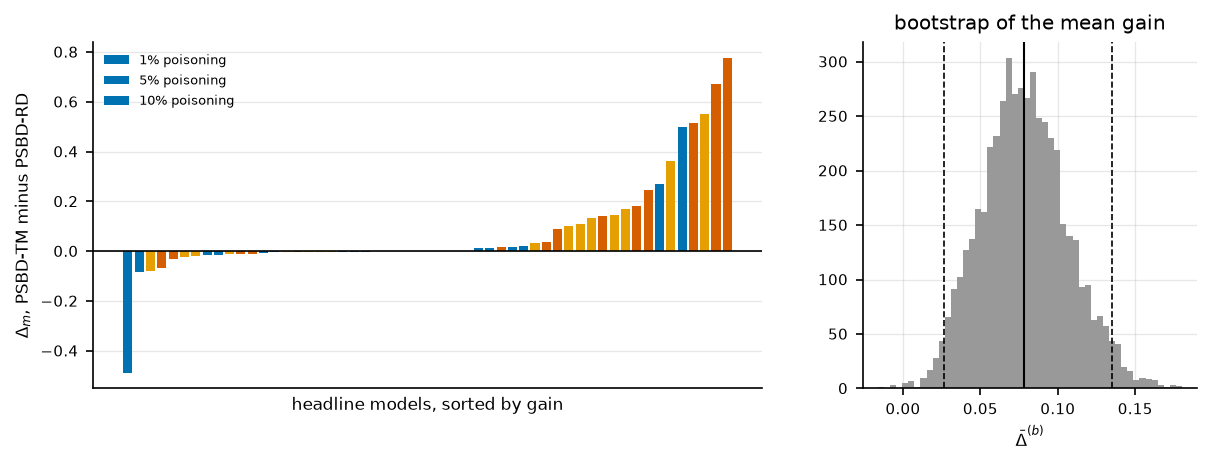


Over the 54 headline models PSBD-TM averages 0.963 and PSBD-RD 0.885, a mean paired gain of +0.078 with a 5000 resample interval of [+0.026, +0.135]. The paper's macros read `HeadlineAurocAdaptive` 0.963, `PublishedAurocAdaptive` 0.885, `HeadlineGainAdaptiveAuroc` +0.078 and the interval [+0.026, +0.135]. Per poison rate:

- 1% poisoning: +0.150 [+0.044, +0.279] over 17 models
- 5% poisoning: +0.077 [+0.018, +0.149] over 19 models
- 10% poisoning: +0.012 [-0.065, +0.097] over 18 models

The left panel shows the per-model gains sorted from lowest to highest and colored by poison rate. The right panel shows the distribution of the resampled means with the printed interval as dashed lines. The reader should see that the mean is carried by a minority of large positive gains (the 6 largest come from 4 badnet_a2o and 2 tact models, where PSBD-RD fails), while most models sit near 0 and 4 are below $-0.05$. That shape is why the interval is wide, and why the per-rate breakdown matters. The histogram draws its resamples with numpy and is illustrative only, while the printed interval uses `bootstrap_ci` exactly as the paper generators do. The last question is how PSBD-TM ranks against the competitor detectors.


In [28]:
show_source(bootstrap_ci, start=-10)

tm_mean = float(np.mean([reading(folder, "PSBD-TM") for folder in PANEL]))
rd_mean = float(np.mean([reading(folder, "PSBD-RD") for folder in PANEL]))
gains = pd.Series({folder: reading(folder, "PSBD-TM") - reading(folder, "PSBD-RD") for folder in PANEL})
low, high = bootstrap_ci(gains.tolist(), BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
rates = models.set_index("folder_name").poison_rate
per_rate = {}
for poison_rate in declaration["panel"]["poison_rates"]:
    subset = gains[[rates[folder] == poison_rate for folder in gains.index]]
    per_rate[poison_rate] = (subset.mean(), *bootstrap_ci(subset.tolist(), BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED), len(subset))

generator = np.random.default_rng(BOOTSTRAP_SEED)
draws = [gains.to_numpy()[generator.integers(0, len(gains), len(gains))].mean() for _ in range(BOOTSTRAP_RESAMPLES)]

figure, (gains_axis, bootstrap_axis) = plt.subplots(1, 2, figsize=(9.5, 3.0), gridspec_kw={"width_ratios": [2, 1]})
ordered = gains.sort_values()
colors = dict(zip(declaration["panel"]["poison_rates"], ("#D55E00", "#E69F00", "#0072B2")))
gains_axis.bar(np.arange(len(ordered)), ordered, color=[colors[rates[folder]] for folder in ordered.index])
for poison_rate, color in colors.items():
    gains_axis.bar([], [], color=color, label=f"{poison_rate:.0%} poisoning")
gains_axis.axhline(0, color="black", linewidth=0.8)
gains_axis.set_xticks([])
gains_axis.set_xlabel("headline models, sorted by gain")
gains_axis.set_ylabel(r"$\Delta_m$, PSBD-TM minus PSBD-RD")
gains_axis.legend(fontsize=6)
bootstrap_axis.hist(draws, bins=50, color="#999999")
bootstrap_axis.axvline(low, color="black", linestyle="--", linewidth=0.8)
bootstrap_axis.axvline(high, color="black", linestyle="--", linewidth=0.8)
bootstrap_axis.axvline(gains.mean(), color="black", linewidth=1.0)
bootstrap_axis.set_xlabel(r"$\bar{\Delta}^{(b)}$")
bootstrap_axis.set_title("bootstrap of the mean gain")
plt.show()

top = gains.nlargest(6)
top_attacks = models.set_index("folder_name").loc[top.index, "attack"].value_counts()
rate_lines = "\n".join(f"- {rate:.0%} poisoning: {mean:+.3f} [{rate_low:+.3f}, {rate_high:+.3f}] over {count} models" for rate, (mean, rate_low, rate_high, count) in per_rate.items())
say(f'''
Over the {len(gains)} headline models PSBD-TM averages {tm_mean:.3f} and PSBD-RD {rd_mean:.3f}, a mean paired gain of {gains.mean():+.3f} with a {BOOTSTRAP_RESAMPLES} resample interval of [{low:+.3f}, {high:+.3f}]. The paper's macros read `HeadlineAurocAdaptive` {macro("HeadlineAurocAdaptive")}, `PublishedAurocAdaptive` {macro("PublishedAurocAdaptive")}, `HeadlineGainAdaptiveAuroc` {macro("HeadlineGainAdaptiveAuroc")} and the interval [{macro("HeadlineGainAdaptiveAurocLow")}, {macro("HeadlineGainAdaptiveAurocHigh")}]. Per poison rate:

{rate_lines}

The left panel shows the per-model gains sorted from lowest to highest and colored by poison rate. The right panel shows the distribution of the resampled means with the printed interval as dashed lines. The reader should see that the mean is carried by a minority of large positive gains (the {len(top)} largest come from {word_list(list(f"{count} {attack}" for attack, count in top_attacks.items()))} models, where PSBD-RD fails), while most models sit near 0 and {int((gains < -0.05).sum())} are below $-0.05$. That shape is why the interval is wide, and why the per-rate breakdown matters. The histogram draws its resamples with numpy and is illustrative only, while the printed interval uses `bootstrap_ci` exactly as the paper generators do. The last question is how PSBD-TM ranks against the competitor detectors.
''')

In [29]:
say(f'''
## The rank among defenses and the margin interval

The competitor comparison reads the {len(DETECTOR_NAMES)} ported detectors of `detectors.DETECTOR_NAMES` ({word_list(list(f"`{name}`" for name in DETECTOR_NAMES))}) on exactly the PSBD split and quantiles, each with low meaning poisoned. `cli.baselines` wrote 1 record per detector per model. The comparison uses only the models on which every defense (PSBD-TM, PSBD-RD and the {len(DETECTOR_NAMES)} competitors) has a reading, because a mean per column over whichever models that column covers would make the columns incomparable. PSBD is read only at the adaptive rule here, since the matched rule is a device for comparing placements with each other.

The rank is computed per metric (AUROC, and TPR at the {BUDGETS[0]:.2f} and {BUDGETS[1]:.2f} budgets) in `scripts/paper/tab_detectors.metric_macros`. Each defense's mean over the compared models is taken and the means are sorted in descending order. PSBD-TM's rank is its position in that order. PSBD-RD's rank is 1 plus the number of defenses with a strictly higher mean. The **margin** is PSBD-TM's mean minus the mean of the strongest competitor detector (the highest of the {len(DETECTOR_NAMES)}, PSBD-RD excluded). Its interval is the same paired bootstrap as above over the per-model differences $A_m^{{TM}} - A_m^{{best}}$. `tab_detectors.py` lists the models by dataset, then attack, then rate. The interval below uses the same order, which is what reproduces the paper's interval under the fixed seed.
''')


## The rank among defenses and the margin interval

The competitor comparison reads the 11 ported detectors of `detectors.DETECTOR_NAMES` (`confidence`, `strip`, `scale_up`, `scale_up_data_limited`, `ibd_psc`, `ibd_psc_calibrated`, `teco`, `cd_l`, `beatrix`, `ted` and `sentinet`) on exactly the PSBD split and quantiles, each with low meaning poisoned. `cli.baselines` wrote 1 record per detector per model. The comparison uses only the models on which every defense (PSBD-TM, PSBD-RD and the 11 competitors) has a reading, because a mean per column over whichever models that column covers would make the columns incomparable. PSBD is read only at the adaptive rule here, since the matched rule is a device for comparing placements with each other.

The rank is computed per metric (AUROC, and TPR at the 0.10 and 0.20 budgets) in `scripts/paper/tab_detectors.metric_macros`. Each defense's mean over the compared models is taken and the means are sorted in descending order. PSBD-TM's rank is its position in that order. PSBD-RD's rank is 1 plus the number of defenses with a strictly higher mean. The **margin** is PSBD-TM's mean minus the mean of the strongest competitor detector (the highest of the 11, PSBD-RD excluded). Its interval is the same paired bootstrap as above over the per-model differences $A_m^{TM} - A_m^{best}$. `tab_detectors.py` lists the models by dataset, then attack, then rate. The interval below uses the same order, which is what reproduces the paper's interval under the fixed seed.


,auroc,tpr_q0.10,tpr_q0.20
models,54,54,54
defenses,13,13,13
rank TM,1,1,1
rank RD,5,3,3
best,ibd_psc_calibrated,ibd_psc_calibrated,ibd_psc_calibrated
best mean,0.935951,0.825006,0.900048
TM mean,0.962962,0.887027,0.915798
margin,0.027011,0.062021,0.01575
low,0.00376,0.004236,-0.027963
high,0.048843,0.120937,0.059492


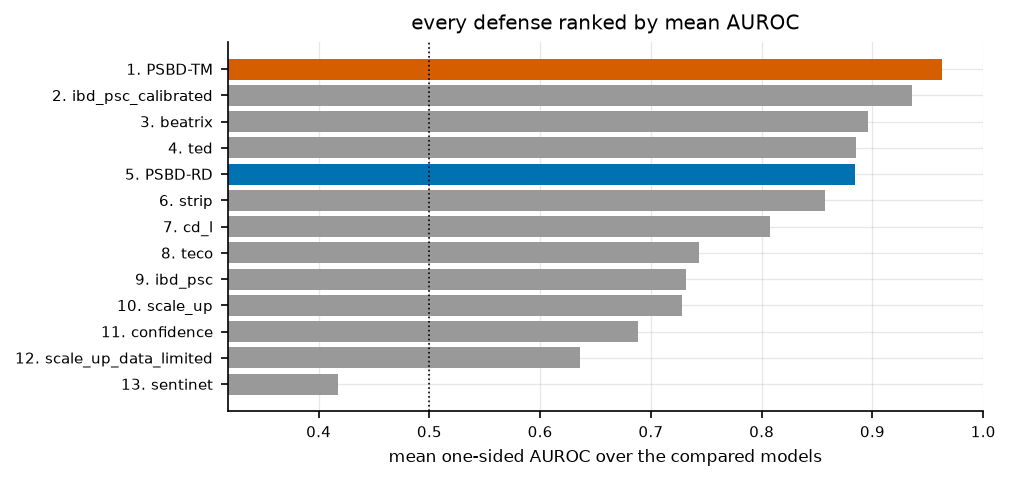


The bar chart lists the 13 defenses in rank order by mean AUROC over the 54 compared models, PSBD-TM in orange, PSBD-RD in blue and the competitors in gray, with the dotted line at chance. The table above it puts the recomputed rank, best competitor, margin and interval of each metric beside the paper's macros. On AUROC PSBD-TM ranks 1 of 13 (paper 1st) and PSBD-RD 5 (paper 5th). The strongest competitor is `ibd_psc_calibrated` at 0.936. PSBD-TM's margin over it is +0.027 [+0.004, +0.049] against the paper's +0.027 [+0.004, +0.049]. The TPR margins are +0.062 [+0.004, +0.121] at the 0.10 budget and +0.016 [-0.028, +0.059] at the 0.20 budget.

The reader should keep 3 limits in mind. The rank is over means, so it says nothing about any single attack, and `notebooks/all-numbers.ipynb` breaks it out per attack and dataset. The compared models are the successful models at the headline bar, so `vit_cifar10_sig_0_1`, whose PSBD cache and detector records hold different triggered images, is not among them. And a rank is not a significance statement, which is why the margin carries its interval.


In [30]:
defenses = ["PSBD-TM", "PSBD-RD", *DETECTOR_NAMES]
clearing_rows = vit[vit.successful_2pt.astype(bool) & (vit.status == "scored") & vit.defense.isin(defenses)]
meta = models.set_index("folder_name")
ranking = {}
for metric, macro_stem in (("auroc", "Auroc"), (f"tpr_q{BUDGETS[0]:.2f}", "TprOneZero"), (f"tpr_q{BUDGETS[1]:.2f}", "TprTwoZero")):
    wide = clearing_rows.pivot(index="folder_name", columns="defense", values=metric)[defenses].dropna()
    order = meta.loc[wide.index].sort_values(["dataset", "attack", "poison_rate"]).index
    wide = wide.loc[order]
    means = wide.mean().sort_values(ascending=False)
    best = means[list(DETECTOR_NAMES)].idxmax()
    margin_low, margin_high = bootstrap_ci((wide["PSBD-TM"] - wide[best]).tolist(), BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
    ranking[metric] = {
        "models": len(wide),
        "defenses": len(means),
        "rank TM": list(means.index).index("PSBD-TM") + 1,
        "rank RD": 1 + int((means > means["PSBD-RD"]).sum()),
        "best": best,
        "best mean": means[best],
        "TM mean": means["PSBD-TM"],
        "margin": means["PSBD-TM"] - means[best],
        "low": margin_low,
        "high": margin_high,
        "paper rank TM": macro(f"Detectors{macro_stem}RankOurs"),
        "paper rank RD": macro(f"Detectors{macro_stem}RankPublished"),
        "paper margin": macro(f"Detectors{macro_stem}Margin"),
        "paper low": macro(f"Detectors{macro_stem}MarginLow"),
        "paper high": macro(f"Detectors{macro_stem}MarginHigh"),
        "means": means,
    }
display(pd.DataFrame({metric: {key: value for key, value in entry.items() if key != "means"} for metric, entry in ranking.items()}))

auroc_means = ranking["auroc"]["means"]
figure, axis = plt.subplots(figsize=(6.5, 3.2))
colors = [TRIGGERED_COLOR if name == "PSBD-TM" else CLEAN_COLOR if name == "PSBD-RD" else "#999999" for name in auroc_means.index]
axis.barh(np.arange(len(auroc_means)), auroc_means.to_numpy(), color=colors)
axis.set_yticks(np.arange(len(auroc_means)), [f"{rank + 1}. {name}" for rank, name in enumerate(auroc_means.index)])
axis.invert_yaxis()
axis.axvline(0.5, color="black", linewidth=0.8, linestyle=":")
axis.set_xlim(max(0.0, float(auroc_means.min()) - 0.1), 1.0)
axis.set_xlabel("mean one-sided AUROC over the compared models")
axis.set_title("every defense ranked by mean AUROC")
plt.show()

auroc_rank = ranking["auroc"]
tpr_low = ranking[f"tpr_q{BUDGETS[0]:.2f}"]
tpr_high = ranking[f"tpr_q{BUDGETS[1]:.2f}"]
say(f'''
The bar chart lists the {auroc_rank["defenses"]} defenses in rank order by mean AUROC over the {auroc_rank["models"]} compared models, PSBD-TM in orange, PSBD-RD in blue and the competitors in gray, with the dotted line at chance. The table above it puts the recomputed rank, best competitor, margin and interval of each metric beside the paper's macros. On AUROC PSBD-TM ranks {auroc_rank["rank TM"]} of {auroc_rank["defenses"]} (paper {auroc_rank["paper rank TM"]}) and PSBD-RD {auroc_rank["rank RD"]} (paper {auroc_rank["paper rank RD"]}). The strongest competitor is `{auroc_rank["best"]}` at {auroc_rank["best mean"]:.3f}. PSBD-TM's margin over it is {auroc_rank["margin"]:+.3f} [{auroc_rank["low"]:+.3f}, {auroc_rank["high"]:+.3f}] against the paper's {auroc_rank["paper margin"]} [{auroc_rank["paper low"]}, {auroc_rank["paper high"]}]. The TPR margins are {tpr_low["margin"]:+.3f} [{tpr_low["low"]:+.3f}, {tpr_low["high"]:+.3f}] at the {BUDGETS[0]:.2f} budget and {tpr_high["margin"]:+.3f} [{tpr_high["low"]:+.3f}, {tpr_high["high"]:+.3f}] at the {BUDGETS[1]:.2f} budget.

The reader should keep 3 limits in mind. The rank is over means, so it says nothing about any single attack, and `notebooks/all-numbers.ipynb` breaks it out per attack and dataset. The compared models are the successful models at the headline bar, so `{SIG}`, whose PSBD cache and detector records hold different triggered images, is not among them. And a rank is not a significance statement, which is why the margin carries its interval.
''')